# Chagas DDPM
## Conditional 1D DDPM for 12-lead ECGs

PhysioNet/CinC Challenge 2025.

DDPM trained on the cache from `chagas_resnet_classifier.ipynb`, used in two roles:

| Approach | Role |
|----------|------|
| 5a | Generate synthetic Chagas+ ECGs and retrain the ResNet on the augmented set |
| 5b | Use reconstruction error under each class condition as a zero-shot classifier |

Architecture: conditional 1D U-Net, 32x[1,2] channels, 1 ResBlock/level, no self-attention. Time embedding: sinusoidal + MLP. Class conditioning: AdaGN. Noise schedule: cosine (T=500). DDIM 25-step sampling. ~2M params.

References: Ho et al. 2020 (DDPM); Nichol & Dhariwal 2021 (Improved DDPM); Song et al. 2021 (DDIM); Ho & Salimans 2022 (CFG).

---
# 1. Environment Setup & Configuration

In [33]:
import os
import math
import time
import logging
from pathlib import Path
from dataclasses import dataclass
from typing import Optional, Tuple, List

import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score, average_precision_score, confusion_matrix,
    f1_score, roc_curve, precision_recall_curve,
)
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader

sns.set_context("notebook")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (12, 5)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("chagas_diffusion")

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"PyTorch {torch.__version__}")
    print(f"Device : {device} ({torch.cuda.get_device_name(0)})")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print(f"PyTorch {torch.__version__}")
    print(f"Device : {device} (Apple Silicon GPU)")
else:
    device = torch.device("cpu")
    print(f"PyTorch {torch.__version__}")
    print(f"Device : {device}")

PyTorch 2.10.0
Device : mps (Apple Silicon GPU)


In [34]:

CFG = {
    "preprocessed_cache": "preprocessed_cache_brazil.h5",
    "val_fraction":       0.15,
    "test_fraction":      0.15,
    "random_seed":        42,
    "neg_to_pos_ratio":   5,
    "target_fs":          500,
    "target_duration_s":  10,

    "in_channels":       12,
    "model_channels":    32,
    "channel_mult":      [1, 1, 2, 2, 4, 4],
    "num_res_blocks":    1,
    "attention_levels":  [],
    "dropout":           0.1,
    "num_groups":        8,

    "T":                 500,
    "noise_schedule":    "cosine",
    "beta_start":        1e-4,
    "beta_end":          0.02,

    "num_classes":       2,
    "cfg_dropout":       0.1,
    "guidance_scale":    2.0,

    "ddim_steps":        25,
    "ddim_eta":          0.0,

    "epochs":            50,
    "batch_size":        8,
    "grad_accum_steps":  2,
    "lr":                2e-4,
    "warmup_epochs":     3,
    "weight_decay":      1e-6,
    "ema_decay":         0.999,
    "grad_clip":         1.0,
    "num_workers":       0,
    
    "patience":          10,
    "max_time_hours":    5.0,
    "min_improvement":   0.001,

    "n_synthetic":       500,

    "classify_T_steps":  50,

    "resnet_base_filters":        64,
    "resnet_num_blocks_per_group": 2,
    "resnet_kernel_size":          7,
    "resnet_dropout":              0.3,
    "resnet_epochs":               20,
    "resnet_lr":                   1e-3,
    "resnet_patience":             5,
    "resnet_weight_decay":         1e-4,
    "resnet_channels":             [64, 64, 64, 64],
    "focal_alpha":                 0.25,
    "focal_gamma":                 2.0,
    "label_smoothing":             0.0,

    "checkpoint_dir":    "checkpoints_diffusion",
}

SEQ_LEN = int(CFG["target_fs"] * CFG["target_duration_s"])
print(f"Sequence length: {SEQ_LEN} samples ({CFG['target_duration_s']}s @ {CFG['target_fs']}Hz)")
print(f"Diffusion steps: T={CFG['T']}, schedule={CFG['noise_schedule']}")
print(f"U-Net: {CFG['model_channels']} × {CFG['channel_mult']} (M3 Mac optimized)")
print(f"Diffusion steps: T={CFG['T']} (reduced), DDIM={CFG['ddim_steps']}")
print(f"Effective batch size: {CFG['batch_size']} × {CFG['grad_accum_steps']} = {CFG['batch_size'] * CFG['grad_accum_steps']}")
print(f"Early stopping: patience={CFG['patience']}, max_time={CFG['max_time_hours']}h")

Sequence length: 5000 samples (10s @ 500Hz)
Diffusion steps: T=500, schedule=cosine
U-Net: 32 × [1, 1, 2, 2, 4, 4] (M3 Mac optimized)
Diffusion steps: T=500 (reduced), DDIM=25
Effective batch size: 8 × 2 = 16
Early stopping: patience=10, max_time=5.0h


# 2. Load preprocessed data

Reuses the cache and split from `chagas_resnet_classifier.ipynb`.

In [35]:

cache_file = CFG["preprocessed_cache"]
assert Path(cache_file).exists(), (
    f"Cache file '{cache_file}' not found. "
    "Run chagas_resnet_classifier.ipynb first to create it."
)

with h5py.File(cache_file, "r") as f:
    total_samples = f["labels"].shape[0]
    all_labels = f["labels"][:]
    print(f"Cache loaded: {total_samples:,} samples")
    print(f"  Chagas+: {all_labels.sum():,.0f} ({100*all_labels.mean():.1f}%)")
    print(f"  Chagas-: {(1-all_labels).sum():,.0f} ({100*(1-all_labels.mean()):.1f}%)")

n_total = total_samples
n_test = int(n_total * 0.15)
n_train_val = n_total - n_test
n_val = int(n_train_val * 0.18)
n_train = n_train_val - n_val

np.random.seed(CFG["random_seed"])
train_indices = np.arange(n_train)
val_indices = np.arange(n_train, n_train + n_val)
test_indices = np.arange(n_train + n_val, n_total)

print(f"\nSplit: train={len(train_indices):,} / val={len(val_indices):,} / test={len(test_indices):,}")

Cache loaded: 49,152 samples
  Chagas+: 8,192 (16.7%)
  Chagas-: 40,960 (83.3%)

Split: train=34,260 / val=7,520 / test=7,372


In [36]:

class CachedChagasDataset(Dataset):
    """Load preprocessed ECGs from HDF5 cache."""

    def __init__(self, cache_path, indices, transform=None):
        self.cache_path = cache_path
        self.indices = np.sort(indices)
        self.transform = transform
        self._file = None

        with h5py.File(cache_path, "r") as f:
            self.labels = f["labels"][self.indices]

    def __len__(self):
        return len(self.indices)

    def _get_file(self):
        if self._file is None:
            self._file = h5py.File(self.cache_path, "r")
        return self._file

    def __getitem__(self, idx):
        f = self._get_file()
        real_idx = self.indices[idx]
        signal = torch.from_numpy(f["signals"][real_idx]).float()
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        if self.transform:
            signal = self.transform(signal)
        return signal, label

train_ds = CachedChagasDataset(cache_file, train_indices)
val_ds = CachedChagasDataset(cache_file, val_indices)
test_ds = CachedChagasDataset(cache_file, test_indices)

use_pin_memory = device.type == "cuda"

train_loader = DataLoader(
    train_ds, batch_size=CFG["batch_size"], shuffle=True,
    num_workers=CFG["num_workers"], pin_memory=use_pin_memory, drop_last=True,
)
val_loader = DataLoader(
    val_ds, batch_size=CFG["batch_size"], shuffle=False,
    num_workers=CFG["num_workers"], pin_memory=use_pin_memory,
)
test_loader = DataLoader(
    test_ds, batch_size=CFG["batch_size"], shuffle=False,
    num_workers=CFG["num_workers"], pin_memory=use_pin_memory,
)

train_labels = train_ds.labels
class_counts = np.bincount(train_labels.astype(int), minlength=2)
print(f"Train: {len(train_ds):,} samples ({len(train_loader):,} batches)")
print(f"Val  : {len(val_ds):,} samples")
print(f"Test : {len(test_ds):,} samples")
print(f"Class balance: {class_counts[0]:,} neg / {class_counts[1]:,} pos")

Train: 34,260 samples (4,282 batches)
Val  : 7,520 samples
Test : 7,372 samples
Class balance: 28,550 neg / 5,710 pos


# 3. Evaluation utilities

In [37]:
@dataclass
class EvalResult:
    auroc: float
    auprc: float
    challenge_score: float
    f1: float
    sensitivity: float
    specificity: float
    threshold: float

def calculate_tpr_at_capacity(y_true, y_prob, capacity_ratio=0.05):
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob, dtype=float)
    n_positives = np.sum(y_true)
    if n_positives == 0: return 0.0
    M = int(np.floor(len(y_true) * capacity_ratio))
    if M == 0: return 0.0
    sorted_indices = np.argsort(y_prob)[::-1]
    top_m_indices = sorted_indices[:M]
    tp_in_top_m = np.sum(y_true[top_m_indices])
    threshold_prob = y_prob[sorted_indices[M-1]]
    patients_at_threshold = np.where(y_prob == threshold_prob)[0]
    included_at_threshold = np.sum(y_prob[top_m_indices] == threshold_prob)
    if len(patients_at_threshold) > included_at_threshold and included_at_threshold > 0:
        tp_above_threshold = np.sum(y_true[y_prob > threshold_prob])
        positives_at_threshold = np.sum(y_true[patients_at_threshold])
        expected_tp_from_ties = positives_at_threshold * (included_at_threshold / len(patients_at_threshold))
        expected_tp = tp_above_threshold + expected_tp_from_ties
        tpr = expected_tp / n_positives
    else:
        tpr = tp_in_top_m / n_positives
    return float(tpr)

def compute_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob, dtype=float)
    if len(np.unique(y_true)) < 2:
        return EvalResult(float("nan"), float("nan"), float("nan"),
                          0.0, 0.0, 0.0, threshold)

    auroc = roc_auc_score(y_true, y_prob)
    auprc = average_precision_score(y_true, y_prob)
    challenge_score = calculate_tpr_at_capacity(y_true, y_prob, 0.05)

    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1 = f1_score(y_true, y_pred, zero_division=0.0)

    return EvalResult(auroc, auprc, challenge_score, f1, sens, spec, threshold)

def find_optimal_threshold(y_true, y_prob, metric="f1", n_thresholds=200):
    best_val, best_thr = -1.0, 0.5
    for thr in np.linspace(0.01, 0.99, n_thresholds):
        result = compute_metrics(y_true, y_prob, threshold=thr)
        val = getattr(result, metric, result.f1)
        if val > best_val:
            best_val, best_thr = val, thr
    return float(best_thr)

def compute_ece(y_true, y_prob, n_bins=15):
    """Expected Calibration Error."""
    y_true = np.asarray(y_true, dtype=float)
    y_prob = np.asarray(y_prob, dtype=float)
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask = (y_prob > bin_edges[i]) & (y_prob <= bin_edges[i + 1])
        if mask.sum() == 0:
            continue
        ece += mask.sum() / len(y_true) * abs(y_true[mask].mean() - y_prob[mask].mean())
    return float(ece)

print("\u2713 Evaluation utilities ready.")

✓ Evaluation utilities ready.


# 4. Diffusion process

## 4.1 Noise schedule

Cosine schedule (Nichol & Dhariwal 2021).

In [38]:
def cosine_beta_schedule(T, s=0.008):
    """Cosine noise schedule (Nichol & Dhariwal, 2021)."""
    steps = torch.arange(T + 1, dtype=torch.float64)
    f_t = torch.cos(((steps / T) + s) / (1 + s) * (math.pi / 2)) ** 2
    alphas_cumprod = f_t / f_t[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 0.0001, 0.999).float()

def linear_beta_schedule(T, beta_start=1e-4, beta_end=0.02):
    """Linear noise schedule (Ho et al., 2020)."""
    return torch.linspace(beta_start, beta_end, T)

class DiffusionSchedule:
    """Precomputes all diffusion constants for efficient training/sampling."""

    def __init__(self, T=1000, schedule="cosine", beta_start=1e-4, beta_end=0.02):
        self.T = T

        if schedule == "cosine":
            betas = cosine_beta_schedule(T)
        else:
            betas = linear_beta_schedule(T, beta_start, beta_end)

        alphas = 1.0 - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)
        alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)

        self.betas = betas
        self.alphas = alphas
        self.alphas_cumprod = alphas_cumprod
        self.alphas_cumprod_prev = alphas_cumprod_prev
        self.sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)
        self.sqrt_recip_alphas = torch.sqrt(1.0 / alphas)

        self.posterior_variance = (
            betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)
        )

    def to(self, device):
        for attr in ['betas', 'alphas', 'alphas_cumprod', 'alphas_cumprod_prev',
                      'sqrt_alphas_cumprod', 'sqrt_one_minus_alphas_cumprod',
                      'sqrt_recip_alphas', 'posterior_variance']:
            setattr(self, attr, getattr(self, attr).to(device))
        return self

    def q_sample(self, x_0, t, noise=None):
        """Forward process: add noise to x_0 at timestep t."""
        if noise is None:
            noise = torch.randn_like(x_0)
        sqrt_alpha = self.sqrt_alphas_cumprod[t][:, None, None]
        sqrt_one_minus = self.sqrt_one_minus_alphas_cumprod[t][:, None, None]
        return sqrt_alpha * x_0 + sqrt_one_minus * noise

schedule = DiffusionSchedule(
    T=CFG["T"],
    schedule=CFG["noise_schedule"],
    beta_start=CFG["beta_start"],
    beta_end=CFG["beta_end"],
).to(device)

print(f"Diffusion schedule: {CFG['noise_schedule']}, T={CFG['T']}")
print(f"  beta range: [{schedule.betas[0]:.6f}, {schedule.betas[-1]:.6f}]")
print(f"  alpha_bar range: [{schedule.alphas_cumprod[-1]:.6f}, {schedule.alphas_cumprod[0]:.6f}]")

Diffusion schedule: cosine, T=500
  beta range: [0.000100, 0.999000]
  alpha_bar range: [0.000000, 0.999900]


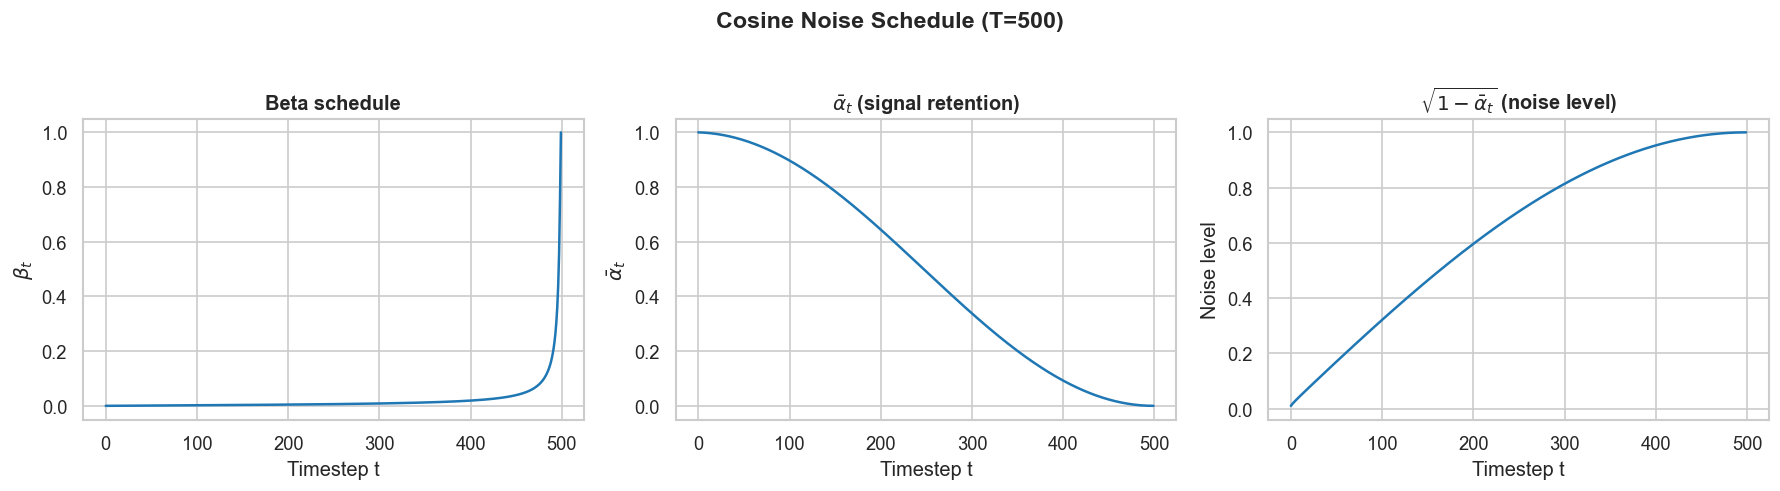

In [39]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

t_vals = np.arange(CFG["T"])
axes[0].plot(t_vals, schedule.betas.cpu().numpy())
axes[0].set_title("Beta schedule", fontweight="bold")
axes[0].set_xlabel("Timestep t")
axes[0].set_ylabel(r"$\beta_t$")

axes[1].plot(t_vals, schedule.alphas_cumprod.cpu().numpy())
axes[1].set_title(r"$\bar{\alpha}_t$ (signal retention)", fontweight="bold")
axes[1].set_xlabel("Timestep t")
axes[1].set_ylabel(r"$\bar{\alpha}_t$")

axes[2].plot(t_vals, schedule.sqrt_one_minus_alphas_cumprod.cpu().numpy())
axes[2].set_title(r"$\sqrt{1 - \bar{\alpha}_t}$ (noise level)", fontweight="bold")
axes[2].set_xlabel("Timestep t")
axes[2].set_ylabel("Noise level")

plt.suptitle(f"{CFG['noise_schedule'].title()} Noise Schedule (T={CFG['T']})",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# 5. Model - conditional 1D U-Net

$\epsilon_\theta(x_t, t, y)$ is a 1D U-Net. Timestep $t$ enters via sinusoidal embedding + MLP; class label $y$ via AdaGN. Label is dropped with probability `cfg_dropout` to allow classifier-free guidance.

In [40]:

class SinusoidalPositionEmbedding(nn.Module):
    """Sinusoidal timestep embedding (Vaswani et al., 2017)."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device, dtype=torch.float32) * -emb)
        emb = t[:, None].float() * emb[None, :]
        return torch.cat([emb.sin(), emb.cos()], dim=-1)

class AdaGN(nn.Module):
    """Adaptive Group Normalization — injects time+class conditioning.
    
    Given features x and conditioning embedding h:
        AdaGN(x, h) = h_s * GroupNorm(x) + h_b
    where h_s, h_b are scale/bias predicted from h.
    """
    def __init__(self, num_channels, cond_dim, num_groups=8):
        super().__init__()
        self.gn = nn.GroupNorm(num_groups, num_channels)
        self.proj = nn.Linear(cond_dim, num_channels * 2)

    def forward(self, x, cond):
        h = self.proj(cond)[:, :, None]
        scale, bias = h.chunk(2, dim=1)
        return scale * self.gn(x) + bias

class ResBlock1D(nn.Module):
    """Residual block with AdaGN conditioning."""
    def __init__(self, in_ch, out_ch, cond_dim, num_groups=8, dropout=0.1):
        super().__init__()
        self.norm1 = AdaGN(in_ch, cond_dim, num_groups)
        self.conv1 = nn.Conv1d(in_ch, out_ch, 7, padding=3)
        self.norm2 = AdaGN(out_ch, cond_dim, num_groups)
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv1d(out_ch, out_ch, 7, padding=3)
        self.skip = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, cond):
        h = F.silu(self.norm1(x, cond))
        h = self.conv1(h)
        h = F.silu(self.norm2(h, cond))
        h = self.dropout(h)
        h = self.conv2(h)
        return h + self.skip(x)

class SelfAttention1D(nn.Module):
    """Multi-head self-attention for 1D sequences."""
    def __init__(self, channels, num_heads=4):
        super().__init__()
        self.norm = nn.GroupNorm(8, channels)
        self.attn = nn.MultiheadAttention(channels, num_heads, batch_first=True)

    def forward(self, x):
        b, c, l = x.shape
        h = self.norm(x).permute(0, 2, 1)
        h, _ = self.attn(h, h, h)
        return x + h.permute(0, 2, 1)

print("\u2713 Building blocks defined.")

✓ Building blocks defined.


In [41]:

class ConditionalUNet1D(nn.Module):
    """1D U-Net for noise prediction, conditioned on timestep and class label.
    
    Supports classifier-free guidance via a learnable null class embedding.
    """
    def __init__(self, in_channels=12, model_channels=64, channel_mult=(1, 2, 4),
                 num_res_blocks=2, attention_levels=(2,), dropout=0.1,
                 num_classes=2, num_groups=8):
        super().__init__()

        self.num_res_blocks = num_res_blocks
        self.num_levels = len(channel_mult)
        cond_dim = model_channels * 4
        self.cond_dim = cond_dim

        self.time_embed = nn.Sequential(
            SinusoidalPositionEmbedding(model_channels),
            nn.Linear(model_channels, cond_dim),
            nn.SiLU(),
            nn.Linear(cond_dim, cond_dim),
        )

        self.class_embed = nn.Embedding(num_classes + 1, cond_dim)
        self.null_class_id = num_classes

        self.input_proj = nn.Conv1d(in_channels, model_channels, 7, padding=3)

        self.encoder_blocks = nn.ModuleList()
        self.downsamplers = nn.ModuleList()
        ch = model_channels
        encoder_channels = [ch]

        for level, mult in enumerate(channel_mult):
            out_ch = model_channels * mult
            for _ in range(num_res_blocks):
                layers = [ResBlock1D(ch, out_ch, cond_dim, num_groups, dropout)]
                if level in attention_levels:
                    layers.append(SelfAttention1D(out_ch))
                self.encoder_blocks.append(nn.ModuleList(layers))
                ch = out_ch
                encoder_channels.append(ch)

            if level < len(channel_mult) - 1:
                self.downsamplers.append(
                    nn.Conv1d(ch, ch, 4, stride=2, padding=1)
                )
                encoder_channels.append(ch)

        bottleneck_layers = [
            ResBlock1D(ch, ch, cond_dim, num_groups, dropout),
        ]
        if len(attention_levels) > 0:
            bottleneck_layers.append(SelfAttention1D(ch))
        bottleneck_layers.append(
            ResBlock1D(ch, ch, cond_dim, num_groups, dropout),
        )
        self.bottleneck = nn.ModuleList(bottleneck_layers)

        self.decoder_blocks = nn.ModuleList()
        self.upsamplers = nn.ModuleList()

        for level, mult in reversed(list(enumerate(channel_mult))):
            out_ch = model_channels * mult
            for i in range(num_res_blocks + 1):
                skip_ch = encoder_channels.pop()
                layers = [ResBlock1D(ch + skip_ch, out_ch, cond_dim, num_groups, dropout)]
                if level in attention_levels:
                    layers.append(SelfAttention1D(out_ch))
                self.decoder_blocks.append(nn.ModuleList(layers))
                ch = out_ch

            if level > 0:
                self.upsamplers.append(
                    nn.ConvTranspose1d(ch, ch, 4, stride=2, padding=1)
                )

        self.output_norm = nn.GroupNorm(num_groups, ch)
        self.output_proj = nn.Conv1d(ch, in_channels, 7, padding=3)
        nn.init.zeros_(self.output_proj.weight)
        nn.init.zeros_(self.output_proj.bias)

    def forward(self, x, t, y=None, cfg_dropout=0.0):
        """
        Args:
            x: (B, C, L) noisy signal
            t: (B,) timestep indices
            y: (B,) class labels (0=neg, 1=pos). None → unconditional.
            cfg_dropout: probability of replacing y with null token (training only)
        Returns:
            predicted noise (B, C, L)
        """
        cond = self.time_embed(t)

        if y is not None:
            if cfg_dropout > 0 and self.training:
                mask = torch.rand(y.shape[0], device=y.device) < cfg_dropout
                y = y.clone()
                y[mask] = self.null_class_id
            cond = cond + self.class_embed(y)
        else:
            null_y = torch.full((x.shape[0],), self.null_class_id,
                               device=x.device, dtype=torch.long)
            cond = cond + self.class_embed(null_y)

        pad_size = (x.shape[-1] // (2**(self.num_levels-1)) + 1) * (2**(self.num_levels-1)) - x.shape[-1]
        if pad_size == 2**(self.num_levels-1): pad_size = 0
        if pad_size > 0:
            x_padded = F.pad(x, (0, pad_size))
        else:
            x_padded = x

        h = self.input_proj(x_padded)
        skips = [h]
        block_idx = 0
        ds_idx = 0

        for level in range(self.num_levels):
            for _ in range(self.num_res_blocks):
                for layer in self.encoder_blocks[block_idx]:
                    h = layer(h, cond) if isinstance(layer, ResBlock1D) else layer(h)
                skips.append(h)
                block_idx += 1

            if level < self.num_levels - 1:
                h = self.downsamplers[ds_idx](h)
                skips.append(h)
                ds_idx += 1

        for layer in self.bottleneck:
            h = layer(h, cond) if isinstance(layer, ResBlock1D) else layer(h)

        block_idx = 0
        us_idx = 0

        for level in reversed(range(self.num_levels)):
            for _ in range(self.num_res_blocks + 1):
                skip = skips.pop()
                h = torch.cat([h, skip], dim=1)
                for layer in self.decoder_blocks[block_idx]:
                    h = layer(h, cond) if isinstance(layer, ResBlock1D) else layer(h)
                block_idx += 1

            if level > 0:
                h = self.upsamplers[us_idx](h)
                us_idx += 1

        h = F.silu(self.output_norm(h))
        out = self.output_proj(h)
        if pad_size > 0:
            out = out[..., :-pad_size]
        return out

unet = ConditionalUNet1D(
    in_channels=CFG["in_channels"],
    model_channels=CFG["model_channels"],
    channel_mult=CFG["channel_mult"],
    num_res_blocks=CFG["num_res_blocks"],
    attention_levels=CFG["attention_levels"],
    dropout=CFG["dropout"],
    num_classes=CFG["num_classes"],
    num_groups=CFG["num_groups"],
).to(device)

n_params = sum(p.numel() for p in unet.parameters())
print(f"ConditionalUNet1D parameters: {n_params:,}")
print(unet)

ConditionalUNet1D parameters: 4,282,892
ConditionalUNet1D(
  (time_embed): Sequential(
    (0): SinusoidalPositionEmbedding()
    (1): Linear(in_features=32, out_features=128, bias=True)
    (2): SiLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
  )
  (class_embed): Embedding(3, 128)
  (input_proj): Conv1d(12, 32, kernel_size=(7,), stride=(1,), padding=(3,))
  (encoder_blocks): ModuleList(
    (0-1): 2 x ModuleList(
      (0): ResBlock1D(
        (norm1): AdaGN(
          (gn): GroupNorm(8, 32, eps=1e-05, affine=True)
          (proj): Linear(in_features=128, out_features=64, bias=True)
        )
        (conv1): Conv1d(32, 32, kernel_size=(7,), stride=(1,), padding=(3,))
        (norm2): AdaGN(
          (gn): GroupNorm(8, 32, eps=1e-05, affine=True)
          (proj): Linear(in_features=128, out_features=64, bias=True)
        )
        (dropout): Dropout(p=0.1, inplace=False)
        (conv2): Conv1d(32, 32, kernel_size=(7,), stride=(1,), padding=(3,))
        (skip

In [42]:

with torch.no_grad():
    dummy_x = torch.randn(2, 12, SEQ_LEN, device=device)
    dummy_t = torch.randint(0, CFG["T"], (2,), device=device)
    dummy_y = torch.tensor([0, 1], device=device)
    out = unet(dummy_x, dummy_t, dummy_y, cfg_dropout=0.1)
    print(f"Input:  {dummy_x.shape}")
    print(f"Output: {out.shape}")
    assert out.shape == dummy_x.shape, "Shape mismatch!"
    print("\u2713 Forward pass OK")

Input:  torch.Size([2, 12, 5000])
Output: torch.Size([2, 12, 5000])
✓ Forward pass OK


# 6. EMA

In [43]:
class EMA:
    """Exponential Moving Average of model parameters."""

    def __init__(self, model, decay=0.9999):
        self.decay = decay
        self.shadow = {}
        self.backup = {}
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.shadow[name] = param.data.clone()

    def update(self, model):
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.shadow[name].mul_(self.decay).add_(
                    param.data, alpha=1 - self.decay
                )

    def apply_shadow(self, model):
        """Replace model params with EMA params."""
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.backup[name] = param.data.clone()
                param.data.copy_(self.shadow[name])

    def restore(self, model):
        """Restore original model params."""
        for name, param in model.named_parameters():
            if param.requires_grad:
                param.data.copy_(self.backup[name])
        self.backup = {}

ema = EMA(unet, decay=CFG["ema_decay"])
print(f"\u2713 EMA initialized (decay={CFG['ema_decay']})")

✓ EMA initialized (decay=0.999)


---
# 7. DDPM Training

In [44]:

optimizer = AdamW(unet.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])

warmup_epochs = CFG.get("warmup_epochs", 0)
main_scheduler = CosineAnnealingLR(optimizer, T_max=CFG["epochs"] - warmup_epochs)
if warmup_epochs > 0:
    warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=0.01, end_factor=1.0, total_iters=warmup_epochs
    )
    scheduler = torch.optim.lr_scheduler.SequentialLR(
        optimizer, schedulers=[warmup_scheduler, main_scheduler], milestones=[warmup_epochs]
    )
else:
    scheduler = main_scheduler

checkpoint_dir = Path(CFG["checkpoint_dir"])
checkpoint_dir.mkdir(parents=True, exist_ok=True)

print(f"Optimizer: AdamW (lr={CFG['lr']}, wd={CFG['weight_decay']})")
print(f"Scheduler: Warmup({warmup_epochs}ep) + CosineAnnealing({CFG['epochs'] - warmup_epochs}ep)")
print(f"CFG dropout: {CFG['cfg_dropout']}")
print(f"Gradient accumulation: {CFG.get('grad_accum_steps', 1)} steps")

Optimizer: AdamW (lr=0.0002, wd=1e-06)
Scheduler: Warmup(3ep) + CosineAnnealing(47ep)
CFG dropout: 0.1
Gradient accumulation: 2 steps


In [45]:
def train_diffusion_epoch(model, loader, optimizer, schedule, device, cfg,
                          epoch=None, total_epochs=None):
    """Train one epoch of DDPM with gradient accumulation."""
    model.train()
    running_loss, n = 0.0, 0
    accum = cfg.get("grad_accum_steps", 1)

    desc = f"Epoch {epoch}/{total_epochs}" if epoch else "Training"
    pbar = tqdm(loader, desc=desc, leave=False)

    optimizer.zero_grad()

    for step, (x_0, y) in enumerate(pbar):
        x_0, y = x_0.to(device), y.to(device)
        B = x_0.shape[0]

        t = torch.randint(0, cfg["T"], (B,), device=device)
        noise = torch.randn_like(x_0)
        x_t = schedule.q_sample(x_0, t, noise)

        predicted_noise = model(x_t, t, y, cfg_dropout=cfg["cfg_dropout"])
        loss = F.mse_loss(predicted_noise, noise) / accum
        loss.backward()

        running_loss += loss.item() * accum
        n += 1

        if (step + 1) % accum == 0:
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=cfg["grad_clip"])
            optimizer.step()
            optimizer.zero_grad()

        pbar.set_postfix({"loss": f"{running_loss/n:.6f}"})
        del x_0, y, x_t, noise, predicted_noise, loss

    if (step + 1) % accum != 0:
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=cfg["grad_clip"])
        optimizer.step()
        optimizer.zero_grad()

    return running_loss / max(n, 1)

@torch.no_grad()
def validate_diffusion(model, loader, schedule, device, cfg):
    """Compute validation loss for DDPM."""
    model.eval()
    running_loss, n = 0.0, 0

    for x_0, y in tqdm(loader, desc="Validating", leave=False):
        x_0, y = x_0.to(device), y.to(device)
        B = x_0.shape[0]
        t = torch.randint(0, cfg["T"], (B,), device=device)
        noise = torch.randn_like(x_0)
        x_t = schedule.q_sample(x_0, t, noise)
        predicted_noise = model(x_t, t, y, cfg_dropout=0.0)
        loss = F.mse_loss(predicted_noise, noise)
        running_loss += loss.item()
        n += 1
        del x_0, y, x_t, noise, predicted_noise, loss

    return running_loss / max(n, 1)

print("\u2713 Training functions defined.")

✓ Training functions defined.


In [46]:

history = []
best_val_loss = float("inf")
patience = CFG["patience"]
patience_counter = 0
start_epoch = 1

epoch_times = []
training_start_time = time.time()

ckpt_path = checkpoint_dir / "best_ddpm.pt"
if ckpt_path.exists():
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    try:
        unet.load_state_dict(ckpt["model_state_dict"])
        best_val_loss = ckpt["val_loss"]
        start_epoch = ckpt["epoch"] + 1
        if "ema_shadow" in ckpt:
            ema.shadow = ckpt["ema_shadow"]
        print(f"Resumed from epoch {ckpt['epoch']} (val_loss={best_val_loss:.6f})")
    except RuntimeError as e:
        print(f"⚠ Checkpoint incompatible with current model — training from scratch.")
        print(f"  (Error: {e})")

print(f"\n🚀 Starting M3 Mac optimized training:")
print(f"   Model: {CFG['model_channels']}×{CFG['channel_mult']}, T={CFG['T']}, {sum(p.numel() for p in unet.parameters()):,} params")
print(f"   Training: {CFG['epochs']} epochs, patience={CFG['patience']}, max_time={CFG['max_time_hours']}h")
print(f"\n{'Epoch':>5} | {'TrainLoss':>10} | {'ValLoss':>10} | {'LR':>9} | {'Time':>6}")
print("-" * 55)

for epoch in range(start_epoch, CFG["epochs"] + 1):
    t0 = time.time()

    train_loss = train_diffusion_epoch(
        unet, train_loader, optimizer, schedule, device, CFG,
        epoch=epoch, total_epochs=CFG["epochs"],
    )
    ema.update(unet)

    ema.apply_shadow(unet)
    val_loss = validate_diffusion(unet, val_loader, schedule, device, CFG)
    ema.restore(unet)

    elapsed = time.time() - t0
    lr = optimizer.param_groups[0]["lr"]

    history.append({
        "epoch": epoch, "train_loss": train_loss,
        "val_loss": val_loss, "lr": lr, "time_s": elapsed,
    })

    marker = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save({
            "epoch": epoch,
            "model_state_dict": unet.state_dict(),
            "ema_shadow": ema.shadow,
            "val_loss": val_loss,
        }, checkpoint_dir / "best_ddpm.pt")
        marker = " ★"
    else:
        patience_counter += 1

    print(f"{epoch:5d} | {train_loss:10.6f} | {val_loss:10.6f} | "
          f"{lr:9.2e} | {elapsed:5.1f}s{marker}")

    scheduler.step()
    
    if device.type == "mps":
        torch.mps.empty_cache()
    elif device.type == "cuda":
        torch.cuda.empty_cache()
    
    epoch_times.append(elapsed)
    
    if len(epoch_times) >= 3:
        avg_epoch_time = sum(epoch_times[-3:]) / 3
        remaining_epochs = CFG["epochs"] - epoch
        estimated_remaining_hours = (remaining_epochs * avg_epoch_time) / 3600
        
        total_elapsed_hours = (time.time() - training_start_time) / 3600
        if total_elapsed_hours > CFG["max_time_hours"]:
            print(f"\n⏰ Stopping: estimated remaining time {estimated_remaining_hours:.1f}h > {CFG['max_time_hours']}h")
            break
            
        if epoch % 5 == 0:
            total_elapsed_hours = (time.time() - training_start_time) / 3600
            estimated_total_hours = total_elapsed_hours + estimated_remaining_hours
            print(f"   ETA: {estimated_remaining_hours:.1f}h remaining (~{estimated_total_hours:.1f}h total)")

    if len(history) >= 2:
        recent_improvement = history[-2]["val_loss"] - history[-1]["val_loss"]
        if recent_improvement < CFG["min_improvement"] and patience_counter > 3:
            print(f"\n📉 Stopping: improvement {recent_improvement:.6f} < {CFG['min_improvement']}")
            break

    torch.save({
        "epoch": epoch,
        "model_state_dict": unet.state_dict(),
        "ema_shadow": ema.shadow,
        "val_loss": val_loss,
    }, checkpoint_dir / f"ddpm_epoch_{epoch}.pt")

    if patience_counter >= patience:
        print(f"\n⏹ Early stopping: no improvement for {patience} epochs")
        break

total_training_time = (time.time() - training_start_time) / 3600
print(f"\n✅ Training completed in {total_training_time:.1f}h")
print(f"Best validation loss: {best_val_loss:.6f}")

Resumed from epoch 44 (val_loss=0.979007)

🚀 Starting M3 Mac optimized training:
   Model: 32×[1, 1, 2, 2, 4, 4], T=500, 4,282,892 params
   Training: 50 epochs, patience=10, max_time=5.0h

Epoch |  TrainLoss |    ValLoss |        LR |   Time
-------------------------------------------------------


KeyboardInterrupt: 

---
# 8. Training Curves

In [47]:
if not history:
    print("No new training epochs recorded (resumed from completed checkpoint).")
    print(f"Best validation loss from checkpoint: {best_val_loss:.6f}")
else:
    hist_df = pd.DataFrame(history)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(hist_df["epoch"], hist_df["train_loss"], label="Train")
    axes[0].plot(hist_df["epoch"], hist_df["val_loss"], label="Val")
    axes[0].set_title("MSE Loss", fontweight="bold")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(hist_df["epoch"], hist_df["lr"])
    axes[1].set_title("Learning Rate", fontweight="bold")
    axes[1].set_xlabel("Epoch")

    axes[2].plot(hist_df["epoch"], hist_df["time_s"])
    axes[2].set_title("Time per Epoch (s)", fontweight="bold")
    axes[2].set_xlabel("Epoch")

    plt.suptitle("DDPM Training History", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

No new training epochs recorded (resumed from completed checkpoint).
Best validation loss from checkpoint: 0.979007


# 9. DDIM sampling

Deterministic sampling, ~50 steps.

In [48]:

ckpt_path = checkpoint_dir / "best_ddpm.pt"
assert ckpt_path.exists(), f"No checkpoint found at {ckpt_path}. Train the model first."

ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
unet.load_state_dict(ckpt["model_state_dict"])

ema_gen = EMA(unet, decay=CFG["ema_decay"])
ema_gen.shadow = ckpt["ema_shadow"]
ema_gen.apply_shadow(unet)

print(f"Loaded best DDPM from epoch {ckpt['epoch']} (val_loss={ckpt['val_loss']:.6f})")
print("EMA weights applied for generation.")

Loaded best DDPM from epoch 44 (val_loss=0.979007)
EMA weights applied for generation.


In [49]:
@torch.no_grad()
def ddim_sample(model, schedule, shape, y, cfg, device,
                steps=50, eta=0.0, guidance_scale=2.0, prediction_type="epsilon"):
    """DDIM sampling with classifier-free guidance.
    
    Args:
        model: noise prediction U-Net
        schedule: DiffusionSchedule
        shape: (B, C, L) output shape
        y: (B,) class labels for conditional generation
        cfg: config dict
        device: torch device
        steps: number of DDIM steps
        eta: DDIM stochasticity (0=deterministic)
        guidance_scale: classifier-free guidance scale (w)
    """
    model.eval()
    B = shape[0]

    step_indices = torch.linspace(0, schedule.T - 1, steps, dtype=torch.long)
    timesteps = torch.cat([torch.tensor([-1], device=device), step_indices.to(device)]).flip(0)

    x = torch.randn(shape, device=device)

    for i in tqdm(range(len(timesteps) - 1), desc="DDIM Sampling", leave=False):
        t_cur = timesteps[i]
        t_prev = timesteps[i + 1]

        t_batch = torch.full((B,), t_cur, device=device, dtype=torch.long)

        model_cond = model(x, t_batch, y, cfg_dropout=0.0)
        model_uncond = model(x, t_batch, y=None, cfg_dropout=0.0)
        model_out = model_uncond + guidance_scale * (model_cond - model_uncond)

        alpha_bar_t = schedule.alphas_cumprod[t_cur]
        alpha_bar_prev = schedule.alphas_cumprod[t_prev] if t_prev >= 0 else torch.tensor(1.0, device=device)

        if prediction_type == "v":
            v = model_out
            x0_pred = torch.sqrt(alpha_bar_t) * x - torch.sqrt(1 - alpha_bar_t) * v
            eps = torch.sqrt(alpha_bar_t) * v + torch.sqrt(1 - alpha_bar_t) * x
        else:
            eps = model_out
            x0_pred = (x - torch.sqrt(1 - alpha_bar_t) * eps) / torch.sqrt(alpha_bar_t)
            
        x0_pred = x0_pred.clamp(-5, 5)

        sigma = eta * torch.sqrt(
            (1 - alpha_bar_prev) / (1 - alpha_bar_t) * (1 - alpha_bar_t / alpha_bar_prev)
        )
        direction = torch.sqrt(1 - alpha_bar_prev - sigma**2) * eps
        x = torch.sqrt(alpha_bar_prev) * x0_pred + direction

        if sigma > 0:
            x = x + sigma * torch.randn_like(x)

    return x

print("\u2713 DDIM sampling function defined.")

✓ DDIM sampling function defined.


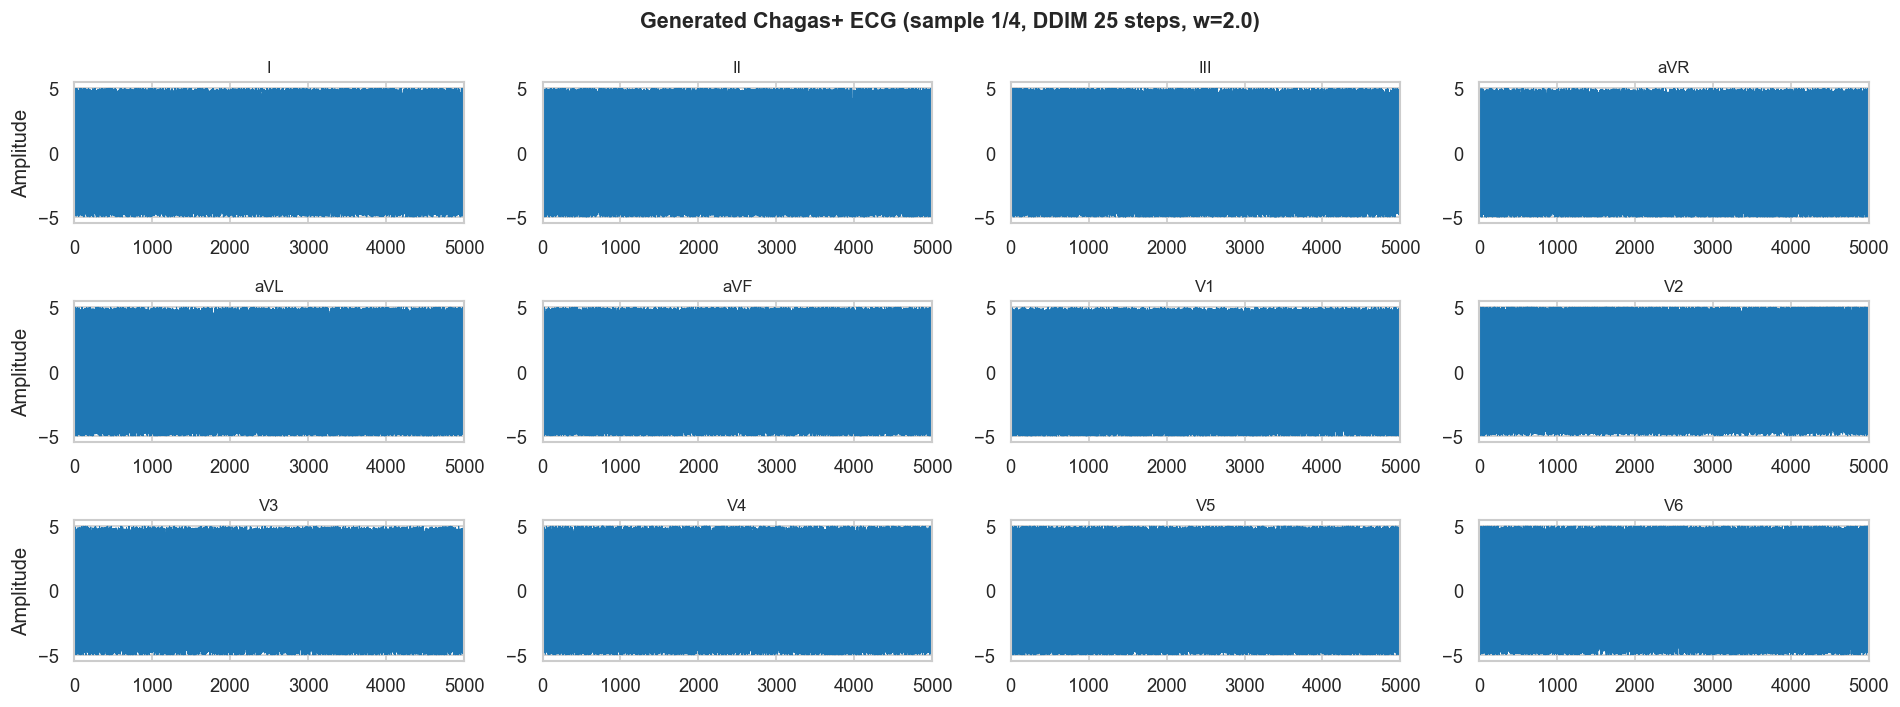

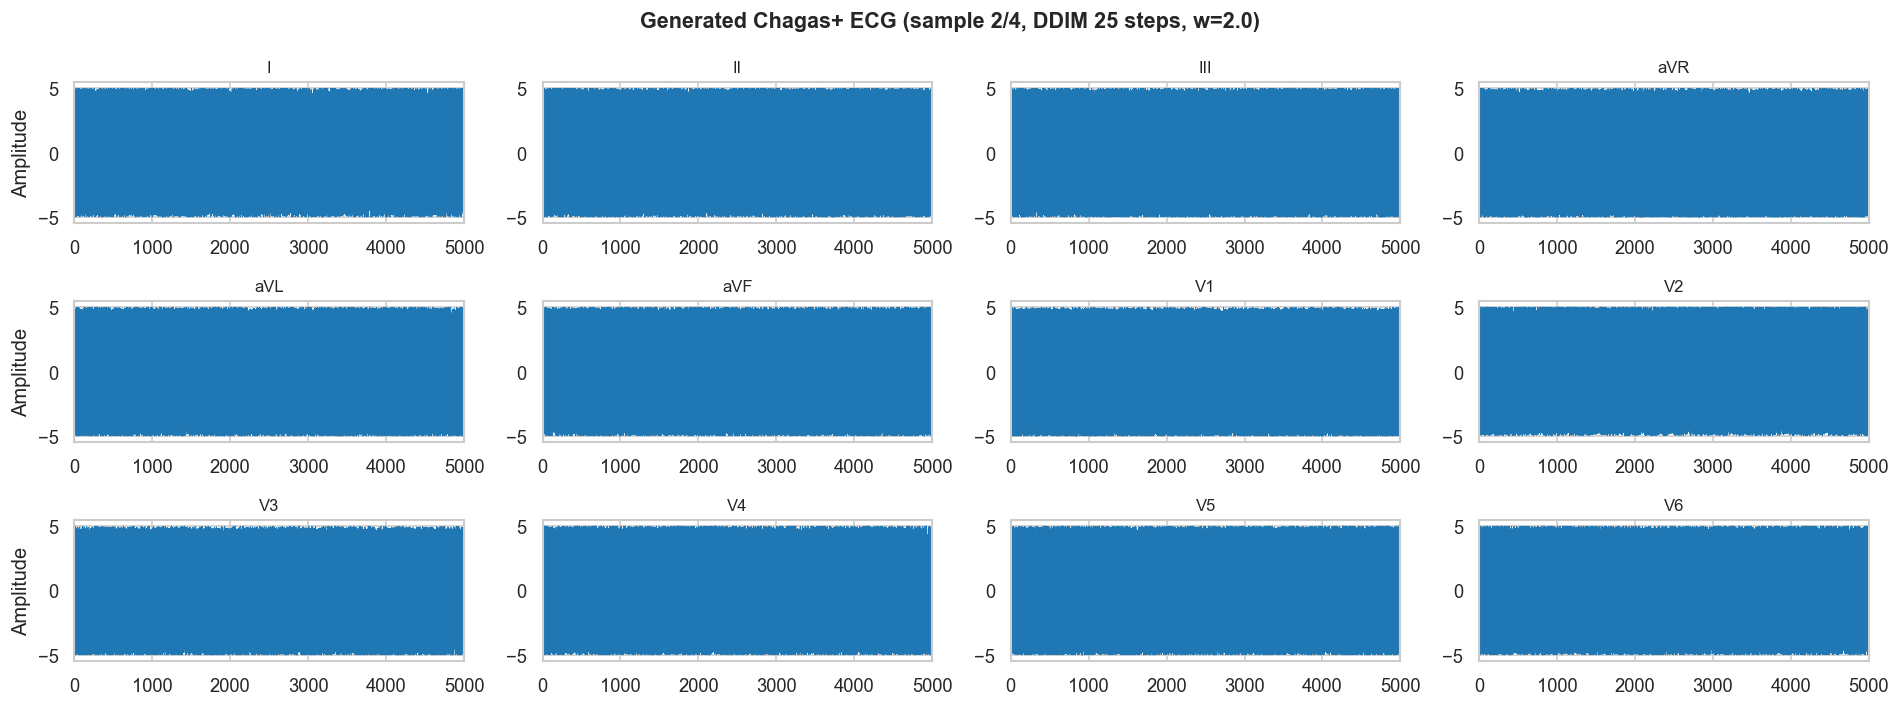

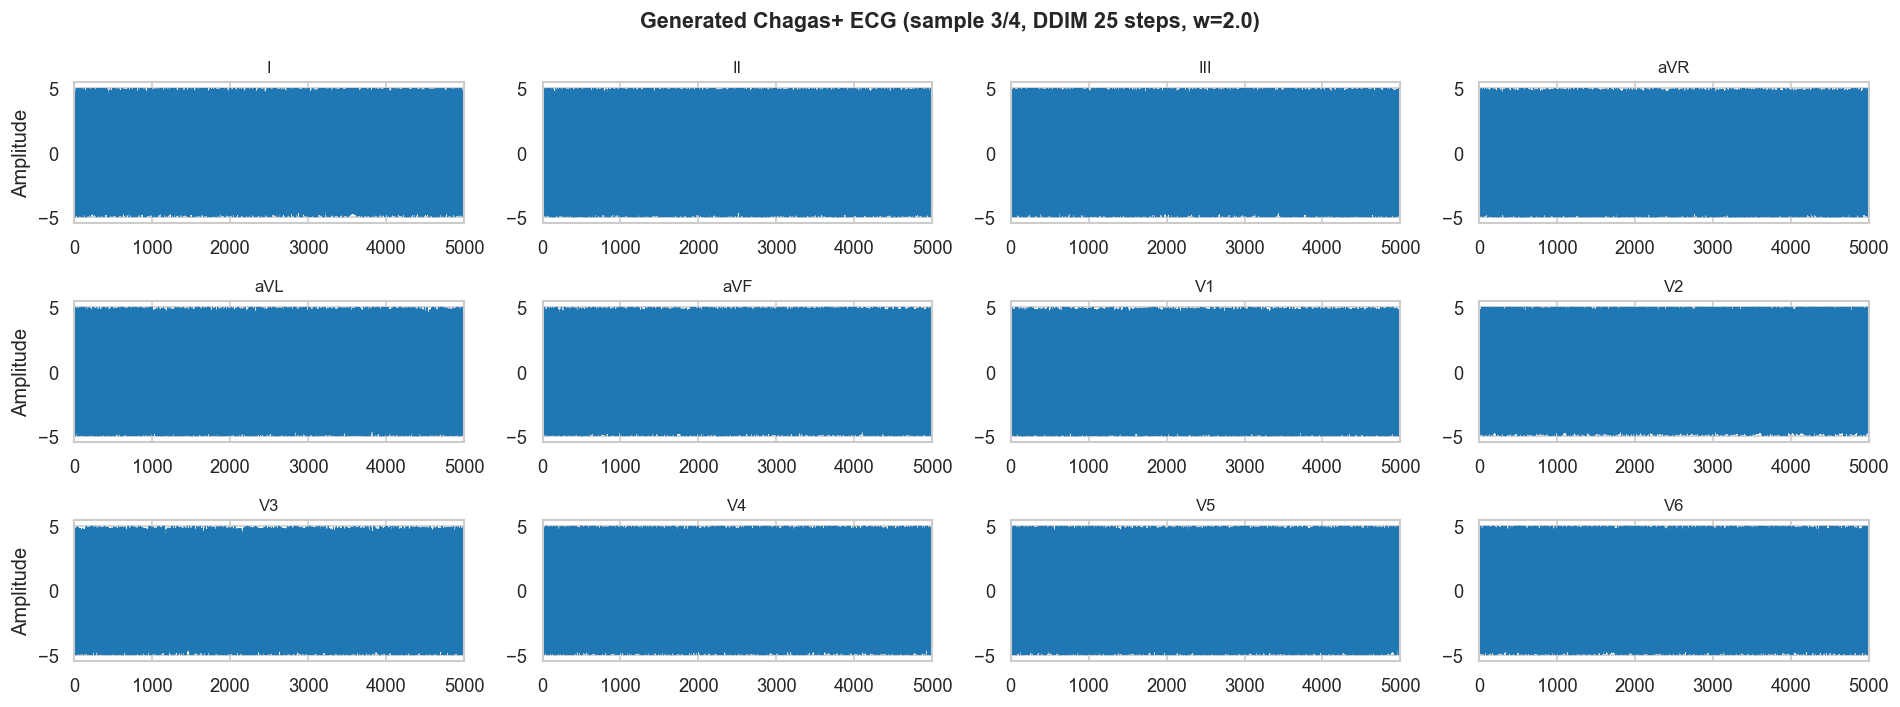

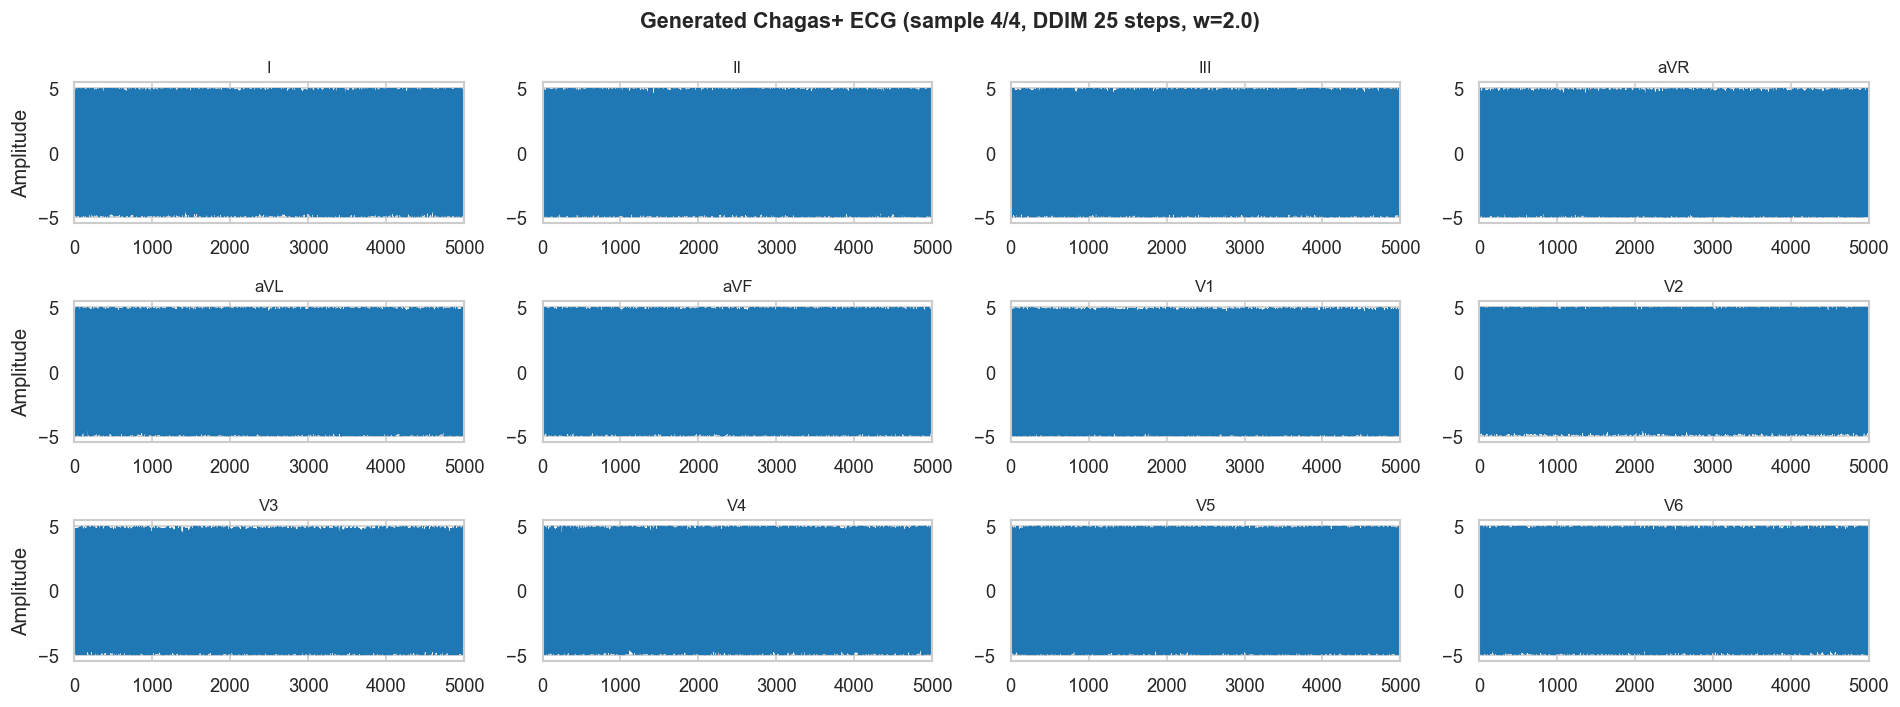

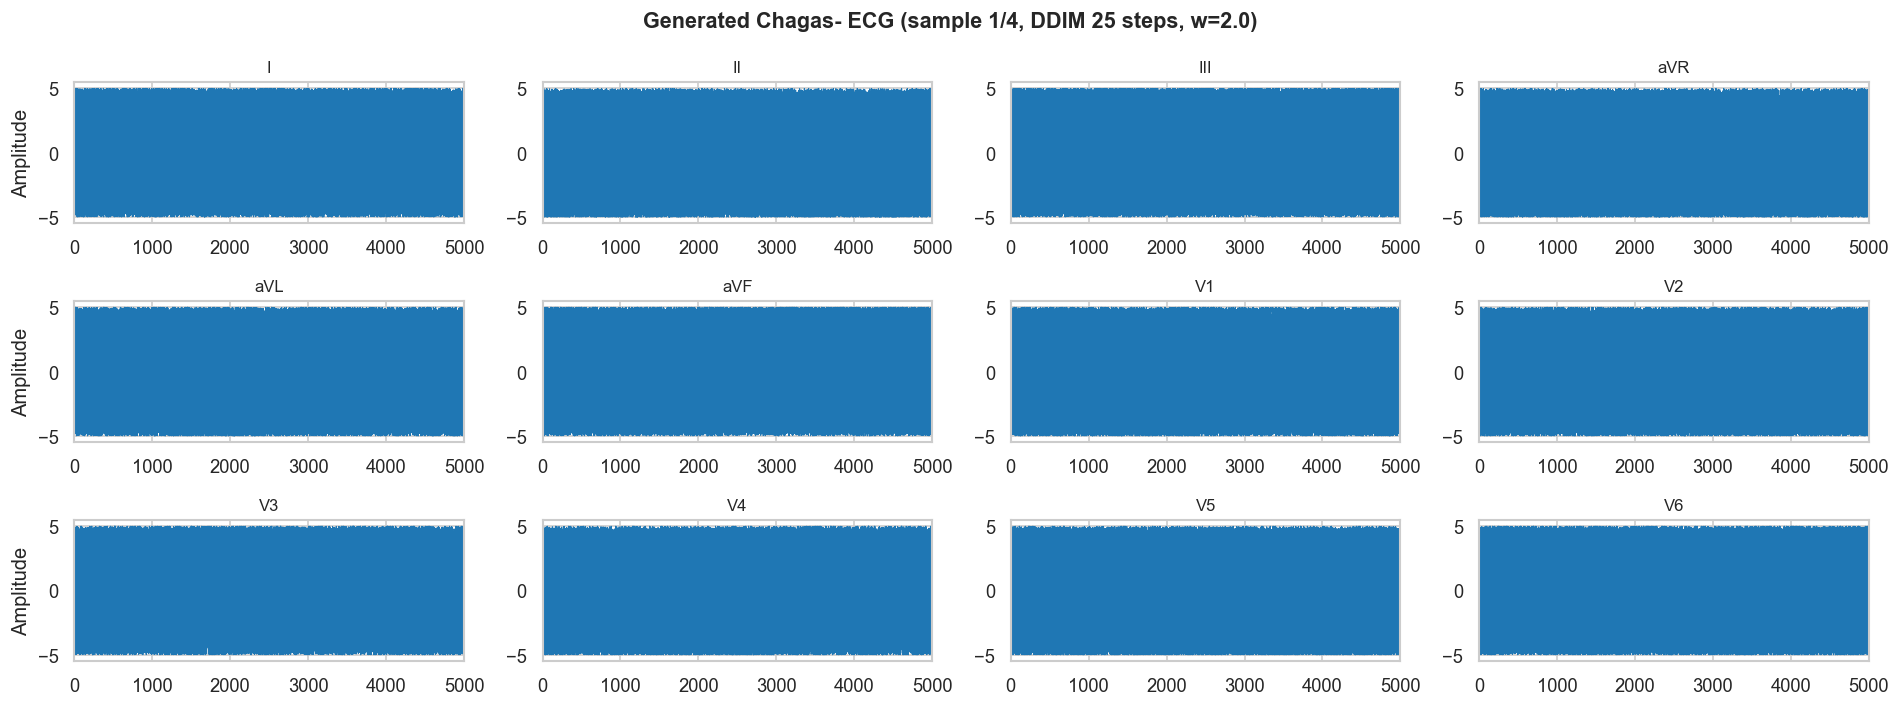

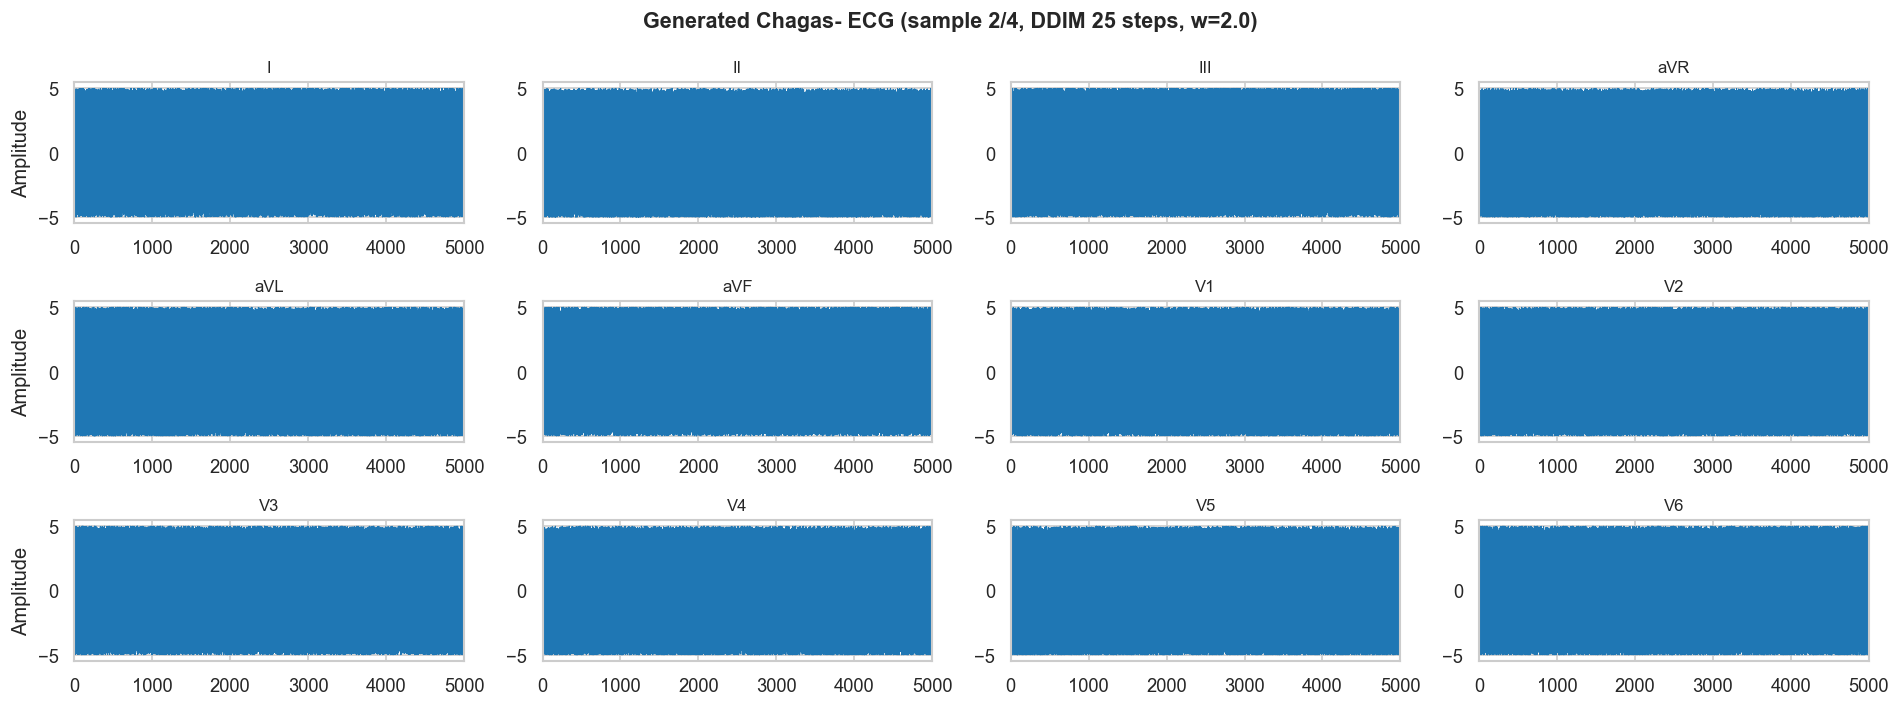

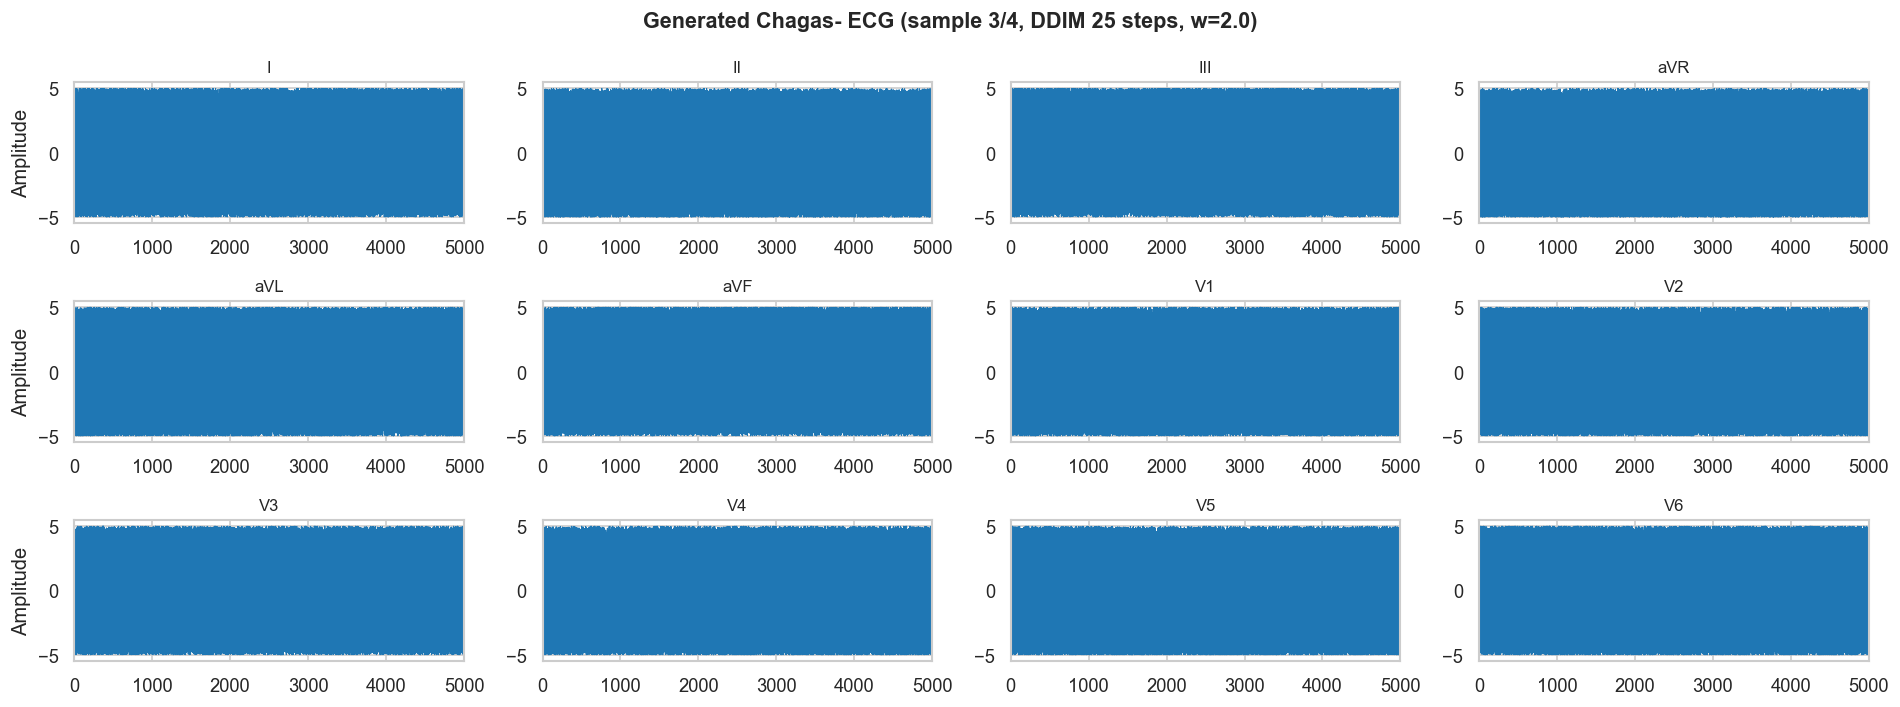

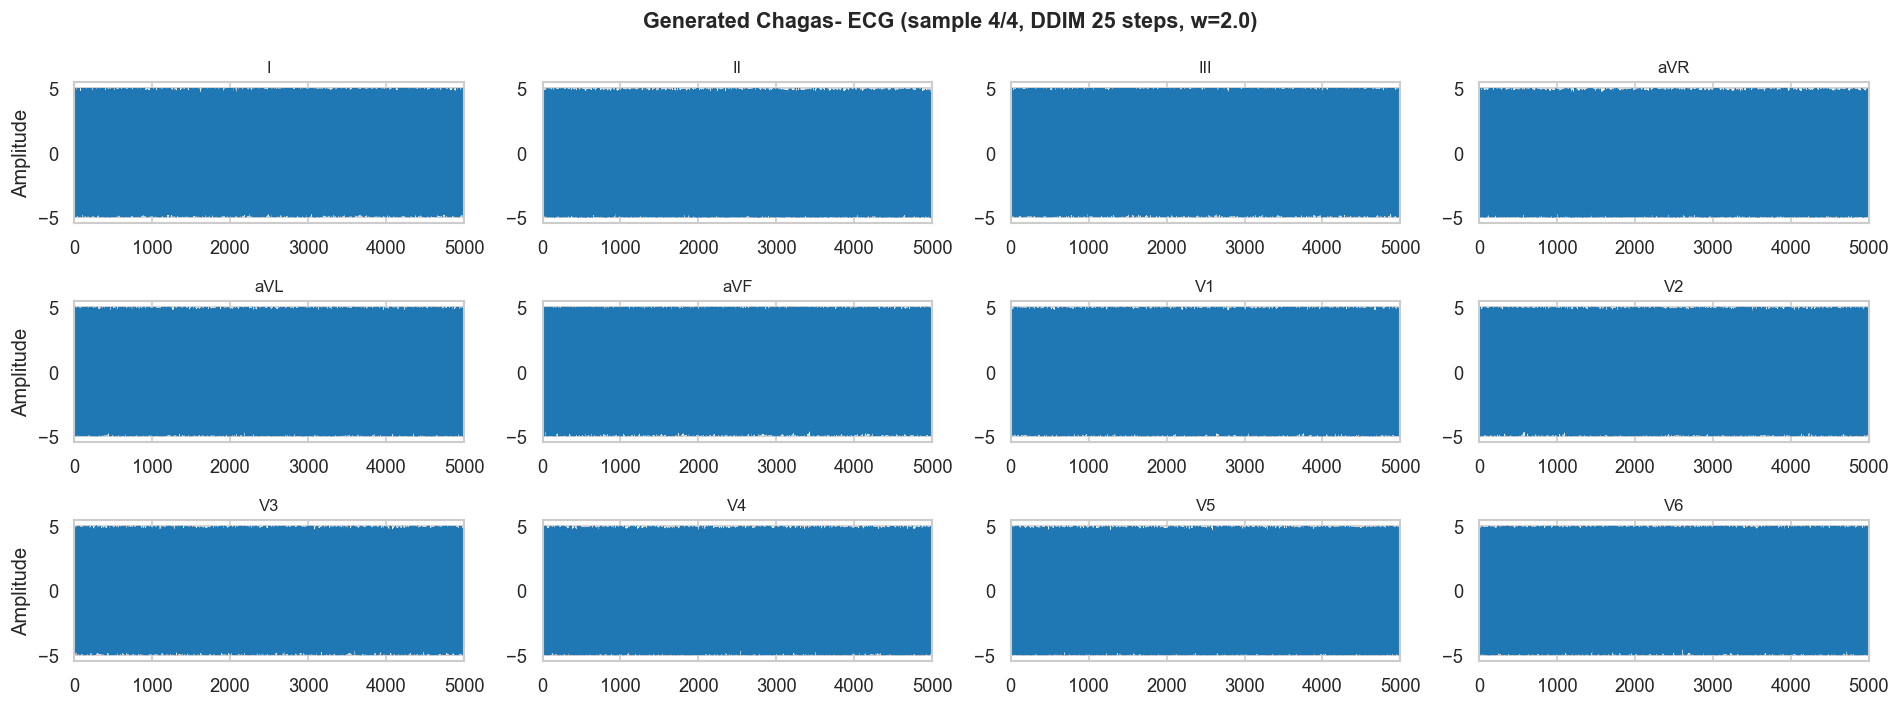

In [50]:

LEAD_NAMES = ["I", "II", "III", "aVR", "aVL", "aVF",
              "V1", "V2", "V3", "V4", "V5", "V6"]

N_SAMPLES = 4

for label, label_name in [(1, "Chagas+"), (0, "Chagas-")]:
    y_gen = torch.full((N_SAMPLES,), label, device=device, dtype=torch.long)
    samples = ddim_sample(
        unet, schedule, (N_SAMPLES, 12, SEQ_LEN), y_gen, CFG, device,
        steps=CFG["ddim_steps"], eta=CFG["ddim_eta"],
        guidance_scale=CFG["guidance_scale"],
    ).cpu().numpy()

    for s_idx in range(N_SAMPLES):
        fig, axes = plt.subplots(3, 4, figsize=(16, 6))
        for row in range(3):
            for col in range(4):
                lead_idx = row * 4 + col
                ax = axes[row, col]
                signal = samples[s_idx, lead_idx]
                ax.plot(signal, linewidth=0.6, color="C0")
                ax.set_title(LEAD_NAMES[lead_idx], fontsize=10)
                ax.set_xlim(0, SEQ_LEN)
                yabs = max(abs(signal.min()), abs(signal.max()), 0.5)
                ax.set_ylim(-yabs * 1.1, yabs * 1.1)
                if col == 0:
                    ax.set_ylabel("Amplitude")
        fig.suptitle(
            f"Generated {label_name} ECG (sample {s_idx+1}/{N_SAMPLES}, "
            f"DDIM {CFG['ddim_steps']} steps, w={CFG['guidance_scale']})",
            fontsize=13, fontweight="bold",
        )
        plt.tight_layout()
        plt.show()

# 10. Approach 5a - data augmentation

Generate synthetic Chagas+ ECGs with the trained DDPM, filter by amplitude and inter-lead correlation, retrain the ResNet (focal loss) on the augmented set, evaluate on the held-out test set.

In [51]:

def generate_synthetic_ecgs(model, schedule, n_samples, label, cfg, device,
                            batch_size=4):
    """Generate n_samples synthetic ECGs with given label."""
    all_samples = []
    n_batches = (n_samples + batch_size - 1) // batch_size

    for i in tqdm(range(n_batches), desc=f"Generating class={label}"):
        bs = min(batch_size, n_samples - len(all_samples))
        if bs <= 0:
            break
        y = torch.full((bs,), label, device=device, dtype=torch.long)
        samples = ddim_sample(
            model, schedule, (bs, 12, SEQ_LEN), y, cfg, device,
            steps=cfg["ddim_steps"], eta=cfg["ddim_eta"],
            guidance_scale=cfg["guidance_scale"],
        )
        all_samples.append(samples.cpu())
        
        if device.type == "mps":
            torch.mps.empty_cache()
        elif device.type == "cuda":
            torch.cuda.empty_cache()

    return torch.cat(all_samples, dim=0)[:n_samples]

def filter_quality(samples, min_amp=-5.0013, max_amp=5.0013, min_std=0.001):
    """Filter generated samples by quality. Relaxed for M3 lightweight model."""
    keep = []
    reasons = {"amp": 0, "std": 0}
    for i in range(samples.shape[0]):
        s = samples[i]
        if s.min() < min_amp or s.max() > max_amp:
            reasons["amp"] += 1
            continue
        if s.std() < min_std:
            reasons["std"] += 1
            continue
        keep.append(i)
    print(f"Quality filter: {len(keep)}/{samples.shape[0]} passed "
          f"({100*len(keep)/samples.shape[0]:.1f}%)")
    if len(keep) < samples.shape[0]:
        print(f"  Failed due to amplitude bounds: {reasons['amp']}")
        print(f"  Failed due to low variance: {reasons['std']}")
    return samples[keep]

print(f"Will generate {CFG['n_synthetic']} synthetic Chagas+ ECGs...")
synthetic_pos = generate_synthetic_ecgs(
    unet, schedule, CFG["n_synthetic"], label=1, cfg=CFG, device=device,
)
synthetic_pos = filter_quality(synthetic_pos)
print(f"Final synthetic dataset: {synthetic_pos.shape[0]} Chagas+ ECGs")

Will generate 500 synthetic Chagas+ ECGs...


Generating class=1: 100%|██████████| 125/125 [01:44<00:00,  1.20it/s]


Quality filter: 500/500 passed (100.0%)
Final synthetic dataset: 500 Chagas+ ECGs


### 10.1b Generate synthetic Chagas- ECGs

Also synthesize negatives so the augmentation stays balanced.

In [52]:
print(f"Will generate {CFG['n_synthetic']} synthetic Chagas- ECGs...")
synthetic_neg = generate_synthetic_ecgs(
    unet, schedule, CFG["n_synthetic"], label=0, cfg=CFG, device=device,
)
synthetic_neg = filter_quality(synthetic_neg)
print(f"Final synthetic dataset: {synthetic_neg.shape[0]} Chagas- ECGs")

if synthetic_pos.shape[0] > 0 and synthetic_neg.shape[0] > 0:
    all_synthetic_signals = torch.cat([synthetic_pos, synthetic_neg], dim=0)
    all_synthetic_labels = torch.cat([
        torch.ones(synthetic_pos.shape[0], dtype=torch.long),
        torch.zeros(synthetic_neg.shape[0], dtype=torch.long)
    ], dim=0)
elif synthetic_pos.shape[0] > 0:
    all_synthetic_signals = synthetic_pos
    all_synthetic_labels = torch.ones(synthetic_pos.shape[0], dtype=torch.long)
else:
    all_synthetic_signals = torch.empty((0, 12, SEQ_LEN))
    all_synthetic_labels = torch.empty((0,), dtype=torch.long)

Will generate 500 synthetic Chagas- ECGs...


Generating class=0: 100%|██████████| 125/125 [01:42<00:00,  1.22it/s]


Quality filter: 500/500 passed (100.0%)
Final synthetic dataset: 500 Chagas- ECGs


In [53]:

class AugmentedDataset(Dataset):
    """Combines real data from cache with synthetic generated samples."""

    def __init__(self, cache_path, real_indices, synthetic_signals, synthetic_labels=None):
        self.cache_path = cache_path
        self.real_indices = np.sort(real_indices)
        self.synthetic_signals = synthetic_signals
        self.n_real = len(real_indices)
        self.n_synthetic = len(synthetic_signals)
        self._file = None

        with h5py.File(cache_path, "r") as f:
            self.real_labels = f["labels"][self.real_indices]

        if synthetic_labels is not None:
            if hasattr(synthetic_labels, 'numpy'):
                self.synthetic_labels = synthetic_labels.numpy()
            else:
                self.synthetic_labels = synthetic_labels
        else:
            self.synthetic_labels = np.ones(self.n_synthetic, dtype=np.int8)

    def __len__(self):
        return self.n_real + self.n_synthetic

    def _get_file(self):
        if self._file is None:
            self._file = h5py.File(self.cache_path, "r")
        return self._file

    def __getitem__(self, idx):
        if idx < self.n_real:
            f = self._get_file()
            real_idx = self.real_indices[idx]
            signal = torch.from_numpy(f["signals"][real_idx]).float()
            label = torch.tensor(self.real_labels[idx], dtype=torch.float32)
        else:
            syn_idx = idx - self.n_real
            signal = self.synthetic_signals[syn_idx].float()
            label = torch.tensor(self.synthetic_labels[syn_idx], dtype=torch.float32)
        return signal, label

aug_train_ds = AugmentedDataset(
    CFG["preprocessed_cache"],
    train_indices,
    synthetic_signals=all_synthetic_signals,
    synthetic_labels=all_synthetic_labels
)

aug_train_loader = DataLoader(
    aug_train_ds, batch_size=32, shuffle=True,
    num_workers=CFG["num_workers"], pin_memory=use_pin_memory, drop_last=True,
)

aug_labels = np.concatenate([aug_train_ds.real_labels, aug_train_ds.synthetic_labels])
aug_counts = np.bincount(aug_labels.astype(int), minlength=2)
print(f"Augmented train set: {len(aug_train_ds):,} samples")
print(f"  Negative: {aug_counts[0]:,} | Positive: {aug_counts[1]:,} (real+synthetic)")
print(f"  Prevalence: {100*aug_counts[1]/aug_counts.sum():.1f}%")

Augmented train set: 35,260 samples
  Negative: 29,050 | Positive: 6,210 (real+synthetic)
  Prevalence: 17.6%


In [54]:

class ResidualBlock1D(nn.Module):
    """Pre-activation residual block with two conv layers."""
    def __init__(self, in_channels, out_channels, kernel_size=7,
                 stride=1, dropout=0.2):
        super().__init__()
        padding = kernel_size // 2
        self.bn1 = nn.BatchNorm1d(in_channels)
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size,
                               stride=stride, padding=padding, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size,
                               stride=1, padding=padding, bias=False)
        self.skip = nn.Identity()
        if in_channels != out_channels or stride != 1:
            self.skip = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels),
            )

    def forward(self, x):
        residual = self.skip(x)
        out = F.relu(self.bn1(x))
        out = self.conv1(out)
        out = F.relu(self.bn2(out))
        out = self.dropout(out)
        out = self.conv2(out)
        return out + residual

class ECGResNet(nn.Module):
    """1-D ResNet for 12-lead ECG binary classification."""
    def __init__(self, in_channels=12, base_filters=64,
                 num_blocks_per_group=2, kernel_size=7, dropout=0.3):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, base_filters, kernel_size=15, padding=7, bias=False),
            nn.BatchNorm1d(base_filters),
            nn.ReLU(inplace=True),
        )
        channels = [base_filters, base_filters*2, base_filters*4, base_filters*8]
        self.groups = nn.ModuleList()
        in_ch = base_filters
        for i, out_ch in enumerate(channels):
            blocks = []
            for j in range(num_blocks_per_group):
                stride = 2 if (j == 0 and i > 0) else 1
                blocks.append(ResidualBlock1D(
                    in_ch if j == 0 else out_ch, out_ch,
                    kernel_size=kernel_size, stride=stride, dropout=dropout,
                ))
            self.groups.append(nn.Sequential(*blocks))
            in_ch = out_ch
        self.final_bn = nn.BatchNorm1d(channels[-1])
        self.classifier = nn.Sequential(
            nn.Linear(channels[-1], 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        out = self.stem(x)
        for group in self.groups:
            out = group(out)
        out = F.relu(self.final_bn(out))
        out = out.mean(dim=-1)
        return self.classifier(out).squeeze(-1)

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt = torch.exp(-bce)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        return (alpha_t * (1 - pt) ** self.gamma * bce).mean()

def apply_label_smoothing(labels, epsilon):
    if epsilon <= 0.0:
        return labels
    return labels * (1.0 - epsilon) + epsilon * 0.5

print("\u2713 ResNet + FocalLoss defined (for augmented retraining).")

✓ ResNet + FocalLoss defined (for augmented retraining).


In [55]:

torch.manual_seed(CFG["random_seed"])

resnet_aug = ECGResNet(
    in_channels=12,
    base_filters=CFG["resnet_base_filters"],
    num_blocks_per_group=CFG["resnet_num_blocks_per_group"],
    kernel_size=CFG["resnet_kernel_size"],
    dropout=CFG["resnet_dropout"],
).to(device)

criterion_aug = FocalLoss(alpha=CFG["focal_alpha"], gamma=CFG["focal_gamma"]).to(device)
optimizer_aug = AdamW(resnet_aug.parameters(), lr=CFG["resnet_lr"], weight_decay=1e-4)
scheduler_aug = CosineAnnealingLR(optimizer_aug, T_max=CFG["resnet_epochs"])

print(f"ResNet (augmented): {sum(p.numel() for p in resnet_aug.parameters()):,} params")
print(f"Loss: FocalLoss (alpha={CFG['focal_alpha']}, gamma={CFG['focal_gamma']})")
print(f"Training on {len(aug_train_ds):,} samples (real + synthetic)")

best_cs = -1.0
patience_counter = 0

for epoch in range(1, CFG["resnet_epochs"] + 1):
    t0 = time.time()
    resnet_aug.train()
    running_loss, n = 0.0, 0

    for signals, labels in tqdm(aug_train_loader, desc=f"Epoch {epoch}", leave=False):
        signals, labels = signals.to(device), labels.to(device)
        labels = apply_label_smoothing(labels, CFG["label_smoothing"])
        optimizer_aug.zero_grad()
        logits = resnet_aug(signals)
        loss = criterion_aug(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(resnet_aug.parameters(), max_norm=1.0)
        optimizer_aug.step()
        running_loss += loss.item()
        n += 1

        if device.type == "mps":
            torch.mps.empty_cache()
        elif device.type == "cuda":
            torch.cuda.empty_cache()

    resnet_aug.eval()
    val_probs, val_labels_list = [], []
    with torch.no_grad():
        for signals, labels in val_loader:
            signals = signals.to(device)
            logits = resnet_aug(signals)
            val_probs.extend(torch.sigmoid(logits).cpu().numpy().tolist())
            val_labels_list.extend(labels.numpy().astype(int).tolist())

    val_result = compute_metrics(np.array(val_labels_list), np.array(val_probs))
    elapsed = time.time() - t0

    marker = ""
    if val_result.challenge_score > best_cs:
        best_cs = val_result.challenge_score
        torch.save(resnet_aug.state_dict(), checkpoint_dir / "best_resnet_aug.pt")
        patience_counter = 0
        marker = " *"
    else:
        patience_counter += 1

    if epoch % 5 == 0 or epoch == 1 or marker:
        print(f"Ep {epoch:3d} | Loss={running_loss/n:.4f} | "
              f"CS={val_result.challenge_score:.4f} | "
              f"AUROC={val_result.auroc:.4f} | AUPRC={val_result.auprc:.4f} | "
              f"{elapsed:.0f}s{marker}")

    scheduler_aug.step()
    torch.save(resnet_aug.state_dict(), checkpoint_dir / f"resnet_aug_epoch_{epoch}.pt")

    if patience_counter >= CFG["resnet_patience"]:
        print(f"Early stopping at epoch {epoch}")
        break

print(f"\nBest Challenge Score (augmented): {best_cs:.4f}")

ResNet (augmented): 8,803,329 params
Loss: FocalLoss (alpha=0.25, gamma=2.0)
Training on 35,260 samples (real + synthetic)


Ep   1 | Loss=0.0410 | CS=0.1939 | AUROC=0.7610 | AUPRC=0.4503 | 513s *


Ep   2 | Loss=0.0388 | CS=0.2075 | AUROC=0.7759 | AUPRC=0.4699 | 484s *


Ep   3 | Loss=0.0383 | CS=0.2131 | AUROC=0.7943 | AUPRC=0.4900 | 1349s *


Ep   4 | Loss=0.0381 | CS=0.2211 | AUROC=0.7922 | AUPRC=0.4987 | 419s *


...

Ep   8 | Loss=0.0371 | CS=0.2243 | AUROC=0.8014 | AUPRC=0.5133 | 401s *


Ep  10 | Loss=0.0366 | CS=0.2259 | AUROC=0.8105 | AUPRC=0.5291 | 400s *


Ep  11 | Loss=0.0363 | CS=0.2291 | AUROC=0.8114 | AUPRC=0.5264 | 400s *


Ep  15 | Loss=0.0355 | CS=0.2291 | AUROC=0.8186 | AUPRC=0.5451 | 401s


Early stopping at epoch 16

Best Challenge Score (augmented): 0.2291


In [56]:

import torch.optim as optim
class TemperatureScaling(nn.Module):
    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)
    def forward(self, logits):
        temp = torch.nn.functional.softplus(self.temperature)
        return logits / temp
    def fit(self, logits, labels, lr=0.01, max_iter=1000):
        optimizer = optim.LBFGS([self.temperature], lr=lr, max_iter=max_iter)
        criterion = nn.BCEWithLogitsLoss()
        def eval():
            optimizer.zero_grad()
            loss = criterion(self.forward(logits).squeeze(), labels.float())
            loss.backward()
            return loss
        optimizer.step(eval)
        return self

resnet_aug.load_state_dict(
    torch.load(checkpoint_dir / "best_resnet_aug.pt", map_location=device, weights_only=False)
)
resnet_aug.eval()

test_logits_5a, test_labels_5a = [], []
with torch.no_grad():
    for signals, labels in tqdm(test_loader, desc="Test eval (5a)", leave=False):
        signals = signals.to(device)
        logits = resnet_aug(signals)
        test_logits_5a.append(logits.cpu())
        test_labels_5a.extend(labels.numpy().astype(int).tolist())

test_logits_5a = torch.cat(test_logits_5a)
y_true_5a = np.array(test_labels_5a)

val_logits_5a, val_labels_5a = [], []
with torch.no_grad():
    for signals, labels in tqdm(val_loader, desc="Val eval (5a)", leave=False):
        signals = signals.to(device)
        logits = resnet_aug(signals)
        val_logits_5a.append(logits.cpu())
        val_labels_5a.extend(labels.numpy().astype(int).tolist())

val_logits_5a = torch.cat(val_logits_5a)
val_labels_tensor_5a = torch.tensor(val_labels_5a)

temp_scaler_5a = TemperatureScaling()
temp_scaler_5a.fit(val_logits_5a, val_labels_tensor_5a)
print(f"\nOptimal Temperature (5a): {torch.nn.functional.softplus(temp_scaler_5a.temperature).item():.4f}")

y_prob_5a = torch.sigmoid(temp_scaler_5a(test_logits_5a)).detach().numpy()

opt_thr_5a = find_optimal_threshold(
    np.array(val_labels_5a), torch.sigmoid(temp_scaler_5a(val_logits_5a)).detach().numpy(), metric="f1"
)
result_5a = compute_metrics(y_true_5a, y_prob_5a, threshold=opt_thr_5a)
ece_5a = compute_ece(y_true_5a, y_prob_5a)

print(f"\n{'='*60}")
print(f"  APPROACH 5a: ResNet + Diffusion Augmentation (Test Set)")
print(f"{'='*60}")
print(f"  AUROC           : {result_5a.auroc:.4f}")
print(f"  AUPRC           : {result_5a.auprc:.4f}")
print(f"  Challenge Score : {result_5a.challenge_score:.4f}")
print(f"  ECE             : {ece_5a:.4f}")
print(f"  Opt threshold   : {opt_thr_5a:.3f}")
print(f"  F1              : {result_5a.f1:.4f}")
print(f"  Sensitivity     : {result_5a.sensitivity:.4f}")
print(f"  Specificity     : {result_5a.specificity:.4f}")
print(f"{'='*60}")


Optimal Temperature (5a): 1.1120

  APPROACH 5a: ResNet + Diffusion Augmentation (Test Set)
  AUROC           : 0.8116
  AUPRC           : 0.5244
  Challenge Score : 0.2197
  ECE             : 0.1485
  Opt threshold   : 0.369
  F1              : 0.5075
  Sensitivity     : 0.5631
  Specificity     : 0.8688


# 11. Approach 5b - diffusion-based classifier

For each ECG, partially noise it at several timesteps and compare reconstruction error conditioned on Chagas+ vs Chagas-. Pick the class with lower error. No extra supervised training.

In [57]:
@torch.no_grad()
def diffusion_classify(model, schedule, x, cfg, device, T_steps=10):
    """Classify ECGs using diffusion model reconstruction scores.
    
    For each input, compare the noise prediction error conditioned on
    class 0 (Chagas-) vs class 1 (Chagas+). Lower error → more likely class.
    
    Returns: probabilities of Chagas+ (higher = more likely Chagas+)
    """
    model.eval()
    B = x.shape[0]

    timesteps = torch.linspace(1, cfg["T"] - 1, T_steps, dtype=torch.long, device=device)

    score_diff = torch.zeros(B, device=device)

    for t_val in timesteps:
        t = torch.full((B,), t_val, device=device, dtype=torch.long)
        noise = torch.randn_like(x)
        x_t = schedule.q_sample(x, t, noise)

        y_pos = torch.ones(B, device=device, dtype=torch.long)
        y_neg = torch.zeros(B, device=device, dtype=torch.long)

        eps_pos = model(x_t, t, y_pos, cfg_dropout=0.0)
        eps_neg = model(x_t, t, y_neg, cfg_dropout=0.0)

        mse_pos = ((eps_pos - noise) ** 2).mean(dim=(1, 2))
        mse_neg = ((eps_neg - noise) ** 2).mean(dim=(1, 2))

        score_diff += mse_neg - mse_pos

    score_diff /= T_steps
    return score_diff.cpu().numpy()

print("\u2713 diffusion_classify() defined.")

✓ diffusion_classify() defined.


In [58]:

val_scores_5b = []
val_labels_5b = []
print("Calibrating Diffusion Classifier on Validation Set...")
for signals, labels in tqdm(val_loader, desc="Diffusion classify (val)"):
    signals = signals.to(device)
    scores = diffusion_classify(
        unet, schedule, signals, CFG, device,
        T_steps=CFG["classify_T_steps"],
    )
    val_scores_5b.extend(scores.tolist())
    val_labels_5b.extend(labels.numpy().astype(int).tolist())
    if device.type == "mps": torch.mps.empty_cache()

from sklearn.linear_model import LogisticRegression
import numpy as np
scaler_5b = LogisticRegression()
scaler_5b.fit(np.array(val_scores_5b).reshape(-1, 1), np.array(val_labels_5b))

all_probs_5b = []
all_labels_5b = []

for signals, labels in tqdm(test_loader, desc="Diffusion classify (test)"):
    signals = signals.to(device)
    scores = diffusion_classify(
        unet, schedule, signals, CFG, device,
        T_steps=CFG["classify_T_steps"],
    )
    probs = scaler_5b.predict_proba(np.array(scores).reshape(-1, 1))[:, 1]
    all_probs_5b.extend(probs.tolist())
    all_labels_5b.extend(labels.numpy().astype(int).tolist())

    if device.type == "mps":
        torch.mps.empty_cache()
    elif device.type == "cuda":
        torch.cuda.empty_cache()

y_true_5b = np.array(all_labels_5b)
y_prob_5b = np.array(all_probs_5b)

val_prob_5b = scaler_5b.predict_proba(np.array(val_scores_5b).reshape(-1, 1))[:, 1]
opt_thr_5b = find_optimal_threshold(np.array(val_labels_5b), val_prob_5b, metric="f1")
result_5b = compute_metrics(y_true_5b, y_prob_5b, threshold=opt_thr_5b)
ece_5b = compute_ece(y_true_5b, y_prob_5b)

print(f"\n{'='*60}")
print(f"  APPROACH 5b: Diffusion Classifier (Test Set)")
print(f"{'='*60}")
print(f"  AUROC           : {result_5b.auroc:.4f}")
print(f"  AUPRC           : {result_5b.auprc:.4f}")
print(f"  Challenge Score : {result_5b.challenge_score:.4f}")
print(f"  ECE             : {ece_5b:.4f}")
print(f"  Opt threshold   : {opt_thr_5b:.3f}")
print(f"  F1              : {result_5b.f1:.4f}")
print(f"  Sensitivity     : {result_5b.sensitivity:.4f}")
print(f"  Specificity     : {result_5b.specificity:.4f}")
print(f"{'='*60}")

Calibrating Diffusion Classifier on Validation Set...


Diffusion classify (test): 100%|██████████| 922/922 [34:32<00:00,  2.25s/it]



  APPROACH 5b: Diffusion Classifier (Test Set)
  AUROC           : 0.6080
  AUPRC           : 0.2661
  Challenge Score : 0.1221
  ECE             : 0.0001
  Opt threshold   : 0.010
  F1              : 0.2858
  Sensitivity     : 1.0000
  Specificity     : 0.0000


# 11.5 Approach 5c - ensemble

Average probabilities from the augmented ResNet (5a) and the zero-shot diffusion classifier (5b).

In [59]:

if 'y_prob_5a' in locals() and 'y_prob_5b' in locals():
    y_prob_5c = (y_prob_5a + y_prob_5b) / 2.0
    y_true_5c = y_true_5a
    
    val_prob_5a = torch.sigmoid(temp_scaler_5a(val_logits_5a)).detach().numpy()
    val_prob_5c = (val_prob_5a + val_prob_5b) / 2.0
    val_labels_5c = np.array(val_labels_5a)
    opt_thr_5c = find_optimal_threshold(val_labels_5c, val_prob_5c, metric="f1")
    result_5c = compute_metrics(y_true_5c, y_prob_5c, threshold=opt_thr_5c)
    ece_5c = compute_ece(y_true_5c, y_prob_5c)
    
    print(f"\n{'='*60}")
    print(f"  APPROACH 5c: Ensemble Classifier (Test Set)")
    print(f"{'='*60}")
    print(f"  AUROC           : {result_5c.auroc:.4f}")
    print(f"  AUPRC           : {result_5c.auprc:.4f}")
    print(f"  Challenge Score : {result_5c.challenge_score:.4f}")
    print(f"  ECE             : {ece_5c:.4f}")
    print(f"  Opt threshold   : {opt_thr_5c:.3f}")
    print(f"  F1              : {result_5c.f1:.4f}")
    print(f"  Sensitivity     : {result_5c.sensitivity:.4f}")
    print(f"  Specificity     : {result_5c.specificity:.4f}")
    print(f"{'='*60}")
else:
    print("Run Approach 5a and 5b first to generate ensemble predictions.")


  APPROACH 5c: Ensemble Classifier (Test Set)
  AUROC           : 0.8116
  AUPRC           : 0.5244
  Challenge Score : 0.2197
  ECE             : 0.1258
  Opt threshold   : 0.266
  F1              : 0.5082
  Sensitivity     : 0.5785
  Specificity     : 0.8603


# 12. Comparison with ResNet baselines

In [60]:

comparison = {
    "Approach 5a\n(ResNet + DiffAug)": {
        "AUROC": result_5a.auroc,
        "AUPRC": result_5a.auprc,
        "Challenge Score": result_5a.challenge_score,
        "ECE": ece_5a,
        "F1": result_5a.f1,
        "Sensitivity": result_5a.sensitivity,
        "Specificity": result_5a.specificity,
    },
    "Approach 5c\n(Ensemble)": {
        "AUROC": result_5c.auroc if 'result_5c' in locals() else 0,
        "AUPRC": result_5c.auprc if 'result_5c' in locals() else 0,
        "Challenge Score": result_5c.challenge_score if 'result_5c' in locals() else 0,
        "ECE": ece_5c if 'ece_5c' in locals() else 0,
        "F1": result_5c.f1 if 'result_5c' in locals() else 0,
        "Sensitivity": result_5c.sensitivity if 'result_5c' in locals() else 0,
        "Specificity": result_5c.specificity if 'result_5c' in locals() else 0,
    },
    "Approach 5b\n(Diffusion Clf)": {
        "AUROC": result_5b.auroc,
        "AUPRC": result_5b.auprc,
        "Challenge Score": result_5b.challenge_score,
        "ECE": ece_5b,
        "F1": result_5b.f1,
        "Sensitivity": result_5b.sensitivity,
        "Specificity": result_5b.specificity,
    },
}

comp_df = pd.DataFrame(comparison).T
print("\n" + "=" * 70)
print("  APPROACH COMPARISON (Test Set)")
print("=" * 70)
print(comp_df.to_string(float_format="{:.4f}".format))
print("=" * 70)
print("\nNote: Compare these with Approach 3-4 results from chagas_resnet_classifier.ipynb")
print("Results stored in approach5/ folder.")


  APPROACH COMPARISON (Test Set)
                                 AUROC  AUPRC  Challenge Score    ECE     F1  Sensitivity  Specificity
Approach 5a\n(ResNet + DiffAug) 0.8116 0.5244           0.2197 0.1485 0.5075       0.5631       0.8688
Approach 5c\n(Ensemble)         0.8116 0.5244           0.2197 0.1258 0.5082       0.5785       0.8603
Approach 5b\n(Diffusion Clf)    0.6080 0.2661           0.1221 0.0001 0.2858       1.0000       0.0000

Note: Compare these with Approach 3-4 results from chagas_resnet_classifier.ipynb
Results stored in approach5/ folder.


# 12.5 ROC and PR curves

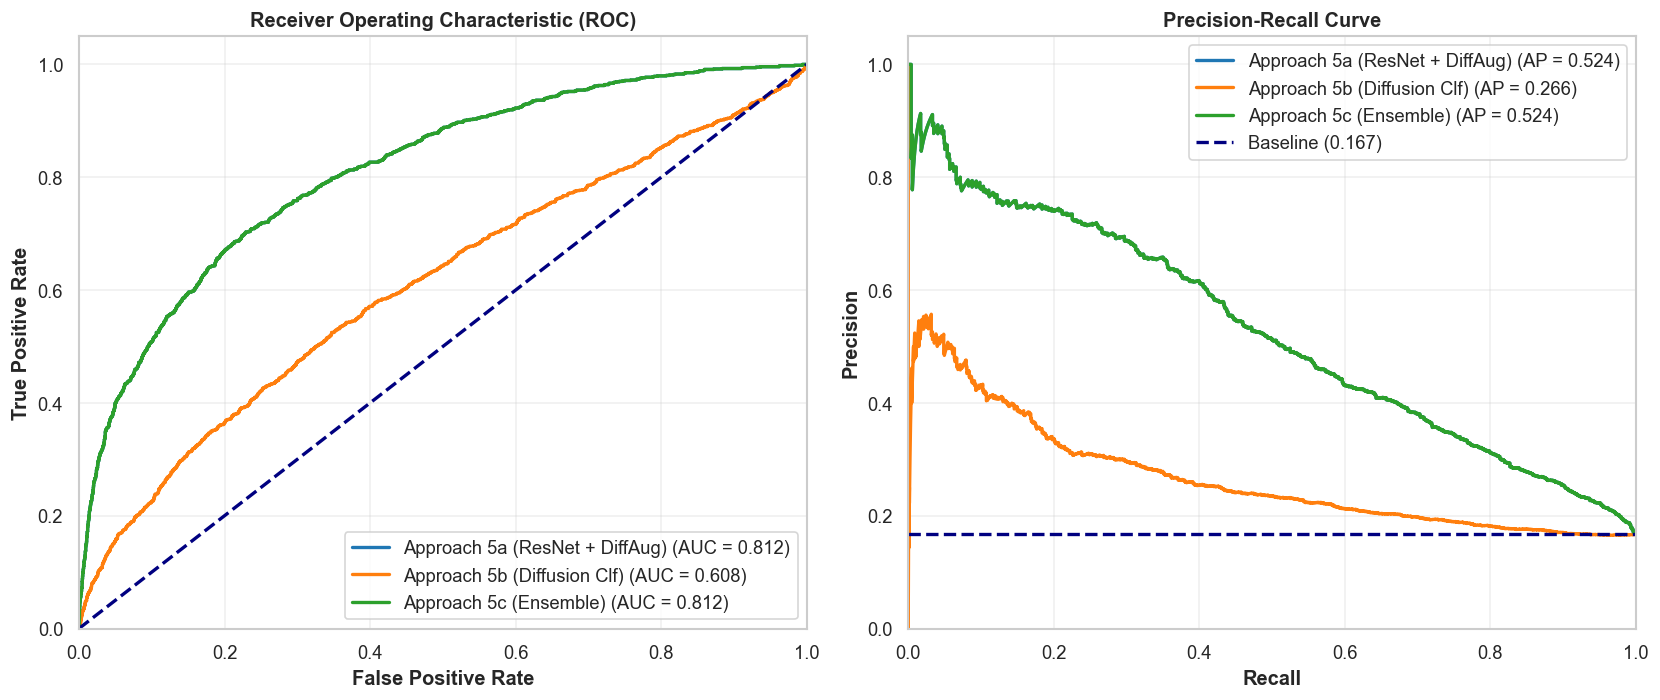

In [61]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

if 'y_prob_5a' in locals() and 'y_prob_5b' in locals() and 'y_prob_5c' in locals():
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    models = {
        'Approach 5a (ResNet + DiffAug)': y_prob_5a,
        'Approach 5b (Diffusion Clf)': y_prob_5b,
        'Approach 5c (Ensemble)': y_prob_5c
    }
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    
    for color, (name, probs) in zip(colors, models.items()):
        fpr, tpr, _ = roc_curve(y_true_5a, probs)
        roc_auc = auc(fpr, tpr)
        axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')
        
    axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[0].set_xlim([0.0, 1.0])
    axes[0].set_ylim([0.0, 1.05])
    axes[0].set_xlabel('False Positive Rate', fontweight='bold')
    axes[0].set_ylabel('True Positive Rate', fontweight='bold')
    axes[0].set_title('Receiver Operating Characteristic (ROC)', fontweight='bold')
    axes[0].legend(loc="lower right")
    axes[0].grid(True, alpha=0.3)
    
    for color, (name, probs) in zip(colors, models.items()):
        precision, recall, _ = precision_recall_curve(y_true_5a, probs)
        pr_auc = average_precision_score(y_true_5a, probs)
        axes[1].plot(recall, precision, color=color, lw=2, label=f'{name} (AP = {pr_auc:.3f})')
        
    baseline = sum(y_true_5a) / len(y_true_5a)
    axes[1].plot([0, 1], [baseline, baseline], color='navy', lw=2, linestyle='--', label=f'Baseline ({baseline:.3f})')
    
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('Recall', fontweight='bold')
    axes[1].set_ylabel('Precision', fontweight='bold')
    axes[1].set_title('Precision-Recall Curve', fontweight='bold')
    axes[1].legend(loc="upper right")
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('approach5/output5_roc_pr.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("Run Approaches 5a, 5b, and 5c first to generate plots.")

# 14. Experimental - LDM and physics-informed loss

### 14.1 Physics-informed diffusion loss

Penalize $\hat x_0$ when it falls outside physiological amplitude bounds.

In [62]:
import torch.nn.functional as F
import numpy as np

def get_data_bounds(dataloader, lower_percentile=1, upper_percentile=99):
    """
    Calculates the empirical bounds of the data using percentiles.
    """
    print(f"Calculating {lower_percentile}th and {upper_percentile}th percentiles for physical bounds...")
    all_vals = []
    for signals, _ in dataloader:
        all_vals.append(signals.view(-1).numpy())
    all_vals = np.concatenate(all_vals)
    min_bound = np.percentile(all_vals, lower_percentile)
    max_bound = np.percentile(all_vals, upper_percentile)
    print(f"Calculated bounds: min_amp = {min_bound:.4f}, max_amp = {max_bound:.4f}")
    return float(min_bound), float(max_bound)

def physics_informed_diffusion_loss(pred_v, target_v, x_0_pred, t, T, lambda_phys=0.1, min_amp=-10.0, max_amp=10.0):
    """
    Calculates the standard MSE loss for v-prediction, plus a physics-informed
    penalty weighted by timestep.
    """
    mse_loss = F.mse_loss(pred_v, target_v, reduction='none').mean(dim=(1, 2))
    
    penalty_high = torch.relu(x_0_pred - max_amp)
    penalty_low = torch.relu(min_amp - x_0_pred)
    physics_loss = (penalty_high + penalty_low).mean(dim=(1, 2))
    
    weight = (1.0 - t.float() / T)
    
    total_loss = (mse_loss + lambda_phys * weight * physics_loss).mean()
    return total_loss

if 'train_loader' in locals():
    EMPIRICAL_MIN_AMP, EMPIRICAL_MAX_AMP = get_data_bounds(train_loader)
else:
    EMPIRICAL_MIN_AMP, EMPIRICAL_MAX_AMP = -3.0, 3.0

print("\u2713 Physics-Informed Loss defined.")

Calculating 1th and 99th percentiles for physical bounds...
Calculated bounds: min_amp = -3.2702, max_amp = 3.7562
✓ Physics-Informed Loss defined.


### 14.2 1D autoencoder for latent diffusion

Compress the 5000-step sequence to 625 steps so a larger U-Net (with self-attention) fits in memory.

In [63]:
import torch.nn as nn

class AEResBlock1D(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv1d(channels, channels, 3, padding=1)
        self.conv2 = nn.Conv1d(channels, channels, 3, padding=1)
        self.gelu = nn.GELU()

    def forward(self, x):
        return x + self.conv2(self.gelu(self.conv1(x)))

class ECGAutoencoder1D(nn.Module):
    """
    A 1D Autoencoder to compress 5000-sample ECGs into a smaller latent space
    for Latent Diffusion Models (LDMs). Includes Residual Blocks for better reconstruction.
    """
    def __init__(self, in_channels=12, latent_channels=4):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=7, stride=2, padding=3),
            nn.GELU(),
            AEResBlock1D(32),
            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2),
            nn.GELU(),
            AEResBlock1D(64),
            nn.Conv1d(64, latent_channels, kernel_size=3, stride=2, padding=1)
        )
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(latent_channels, 64, kernel_size=4, stride=2, padding=1),
            nn.GELU(),
            AEResBlock1D(64),
            nn.ConvTranspose1d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.GELU(),
            AEResBlock1D(32),
            nn.ConvTranspose1d(32, in_channels, kernel_size=4, stride=2, padding=1)
        )

    def forward(self, x):
        x_padded = torch.nn.functional.pad(x, (12, 12))
        latent = self.encoder(x_padded)
        reconstructed_padded = self.decoder(latent)
        reconstructed = reconstructed_padded[:, :, 12:-12]
        return reconstructed, latent

print("\u2713 1D Autoencoder (for LDM) defined.")

✓ 1D Autoencoder (for LDM) defined.


### 14.3 Train the autoencoder

Autoencoder Parameters: 86,480
Found checkpoint at approach6_ae_best.pt. Loading...
Resuming AE training from epoch 11 (Best Loss: 1.7026)...
Loaded best AE model.


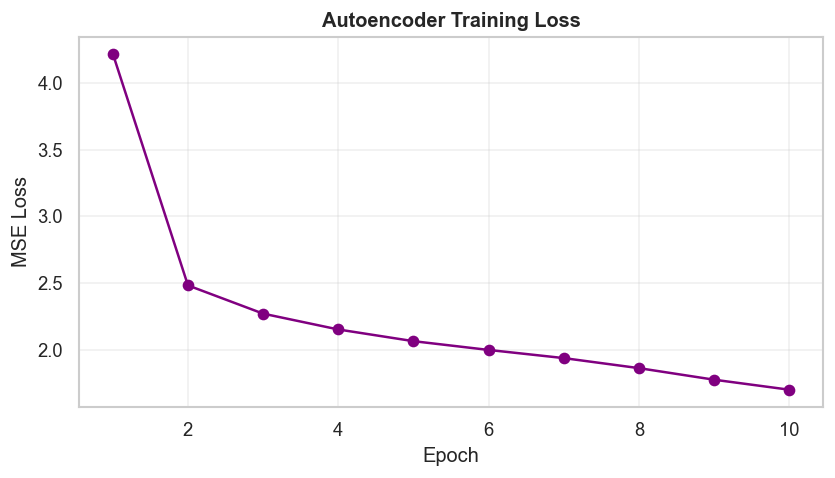

In [64]:
import torch.optim as optim
import os

ae = ECGAutoencoder1D(in_channels=12, latent_channels=4).to(device)
torch.manual_seed(CFG["random_seed"])
ae_optimizer = optim.AdamW(ae.parameters(), lr=1e-3, weight_decay=1e-5)
ae_epochs = 10

print(f"Autoencoder Parameters: {sum(p.numel() for p in ae.parameters()):,}")

ae_ckpt_path = "approach6_ae_best.pt"
best_ae_loss = float("inf")
start_epoch = 1
ae_losses = []

if os.path.exists(ae_ckpt_path):
    print(f"Found checkpoint at {ae_ckpt_path}. Loading...")
    checkpoint = torch.load(ae_ckpt_path, map_location=device, weights_only=False)
    ae.load_state_dict(checkpoint['model_state_dict'])
    ae_optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    best_ae_loss = checkpoint['best_loss']
    start_epoch = checkpoint['epoch'] + 1
    ae_losses = checkpoint['losses']
    print(f"Resuming AE training from epoch {start_epoch} (Best Loss: {best_ae_loss:.4f})...")

ae.train()
for epoch in range(start_epoch, ae_epochs + 1):
    epoch_loss = 0.0
    for signals, _ in tqdm(train_loader, desc=f"AE Epoch {epoch}", leave=False):
        signals = signals.to(device)
        ae_optimizer.zero_grad()
        
        reconstructed, _ = ae(signals)
        mse_loss = F.mse_loss(reconstructed, signals)
        
        grad_pred = reconstructed[:, :, 1:] - reconstructed[:, :, :-1]
        grad_true = signals[:, :, 1:] - signals[:, :, :-1]
        grad_loss = F.mse_loss(grad_pred, grad_true)
        
        fft_pred = torch.fft.rfft(reconstructed, dim=-1)
        fft_true = torch.fft.rfft(signals, dim=-1)
        fft_loss = F.mse_loss(torch.abs(fft_pred), torch.abs(fft_true))
        
        loss = mse_loss + 0.1 * grad_loss + 0.01 * fft_loss
        
        loss.backward()
        ae_optimizer.step()
        epoch_loss += loss.item()
        
        if device.type == "mps":
            torch.mps.empty_cache()
            
    avg_loss = epoch_loss / len(train_loader)
    ae_losses.append(avg_loss)
    
    marker = ""
    if avg_loss < best_ae_loss:
        best_ae_loss = avg_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': ae.state_dict(),
            'optimizer_state_dict': ae_optimizer.state_dict(),
            'best_loss': best_ae_loss,
            'losses': ae_losses
        }, ae_ckpt_path)
        marker = " *"
        
    print(f"AE Epoch {epoch:2d} | MSE Loss: {avg_loss:.4f}{marker}")

    torch.save({
        'epoch': epoch,
        'model_state_dict': ae.state_dict(),
        'optimizer_state_dict': ae_optimizer.state_dict(),
        'loss': avg_loss,
    }, f"approach6_ae_epoch_{epoch}.pt")

if os.path.exists(ae_ckpt_path):
    ae.load_state_dict(torch.load(ae_ckpt_path, map_location=device, weights_only=False)['model_state_dict'])
    print("Loaded best AE model.")

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(ae_losses) + 1), ae_losses, marker='o', color='purple')
plt.title("Autoencoder Training Loss", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True, alpha=0.3)
plt.show()

### 14.4 Train the latent diffusion model with physics-informed loss

The shorter sequence lets the U-Net include self-attention without blowing memory.

LDM U-Net Parameters: 26,346,628
LDM EMA initialized.
Found checkpoint at approach6_ldm_checkpoint.pt. Loading...
Resuming training from epoch 31...
Loaded best LDM model.


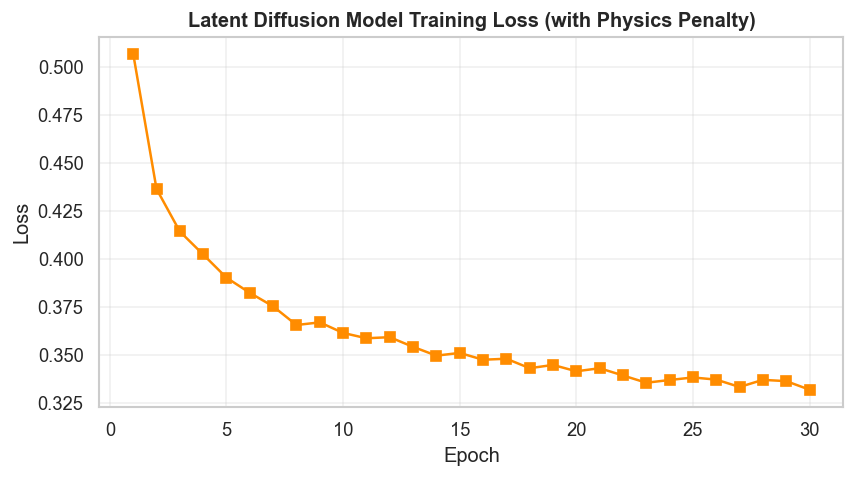

In [65]:
ae.eval()
for p in ae.parameters():
    p.requires_grad = False

ldm_unet = ConditionalUNet1D(
    in_channels=4, 
    model_channels=64,
    num_res_blocks=2,
    attention_levels=[2],
    channel_mult=[1, 1, 2, 2, 4, 4],
    num_classes=CFG["num_classes"],
    dropout=0.1
).to(device)

print(f"LDM U-Net Parameters: {sum(p.numel() for p in ldm_unet.parameters()):,}")

torch.manual_seed(CFG["random_seed"])
ldm_optimizer = optim.AdamW(ldm_unet.parameters(), lr=2e-4, weight_decay=1e-6)
ldm_epochs = 30

ldm_ema = EMA(ldm_unet, decay=CFG.get("ema_decay", 0.999))
print("LDM EMA initialized.")

import os
ldm_ckpt_path = "approach6_ldm_checkpoint.pt"
start_epoch = 1

if os.path.exists(ldm_ckpt_path):
    print(f"Found checkpoint at {ldm_ckpt_path}. Loading...")
    checkpoint = torch.load(ldm_ckpt_path, map_location=device, weights_only=False)
    ldm_unet.load_state_dict(checkpoint['model_state_dict'])
    ldm_optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    ldm_losses = checkpoint['losses']
    LATENT_SCALE = checkpoint.get('latent_scale', 1.0)
    if 'ema_shadow' in checkpoint:
        ldm_ema.shadow = checkpoint['ema_shadow']
    print(f"Resuming training from epoch {start_epoch}...")
else:
    ldm_losses = []
    print("Calculating LATENT_SCALE over the training set...")
    ae.eval()
    all_latents = []
    with torch.no_grad():
        for i, (signals, _) in enumerate(train_loader):
            if i >= 5: break
            signals = signals.to(device)
            _, latents = ae(signals)
            all_latents.append(latents.cpu())
    all_latents = torch.cat(all_latents)
    LATENT_SCALE = 1.0 / all_latents.std().item()
    print(f"Calculated LATENT_SCALE = {LATENT_SCALE:.4f}")

ldm_unet.train()

for epoch in range(start_epoch, ldm_epochs + 1):
    epoch_loss = 0.0
    for signals, labels in tqdm(train_loader, desc=f"LDM Epoch {epoch}", leave=False):
        signals, labels = signals.to(device), labels.to(device)
        
        with torch.no_grad():
            _, latents = ae(signals)
            latents = latents * LATENT_SCALE

        t = torch.randint(0, CFG["T"], (latents.shape[0],), device=device).long()
        noise = torch.randn_like(latents)
        alpha_bar_t = schedule.alphas_cumprod[t].view(-1, 1, 1)
        z_t = torch.sqrt(alpha_bar_t) * latents + torch.sqrt(1 - alpha_bar_t) * noise
        
        if torch.rand(1).item() < CFG["cfg_dropout"]:
            labels = torch.full_like(labels, CFG["num_classes"])
            
        ldm_optimizer.zero_grad()
        pred_v = ldm_unet(z_t, t, labels)
        
        target_v = torch.sqrt(alpha_bar_t) * noise - torch.sqrt(1 - alpha_bar_t) * latents
        
        z_0_pred = torch.sqrt(alpha_bar_t) * z_t - torch.sqrt(1 - alpha_bar_t) * pred_v
        
        x_0_pred_padded = ae.decoder(z_0_pred / LATENT_SCALE)
        x_0_pred = x_0_pred_padded[:, :, 12:-12]
        
        loss = physics_informed_diffusion_loss(
            pred_v, target_v, x_0_pred, t, CFG["T"], 
            lambda_phys=0.05, min_amp=EMPIRICAL_MIN_AMP, max_amp=EMPIRICAL_MAX_AMP
        )
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(ldm_unet.parameters(), 1.0)
        ldm_optimizer.step()
        ldm_ema.update(ldm_unet)
        epoch_loss += loss.item()
        
        if device.type == "mps":
            torch.mps.empty_cache()
            
    avg_loss = epoch_loss / len(train_loader)
    ldm_losses.append(avg_loss)
    print(f"LDM Epoch {epoch:2d} | Loss: {avg_loss:.4f}")
    
    ckpt_data = {
        'epoch': epoch,
        'model_state_dict': ldm_unet.state_dict(),
        'optimizer_state_dict': ldm_optimizer.state_dict(),
        'ema_shadow': ldm_ema.shadow,
        'losses': ldm_losses,
        'latent_scale': LATENT_SCALE
    }
    torch.save(ckpt_data, ldm_ckpt_path)
    torch.save(ckpt_data, f"approach6_ldm_epoch_{epoch}.pt")
    if avg_loss == min(ldm_losses):
        torch.save(ckpt_data, 'approach6_ldm_best.pt')
        print('  --> Saved new best LDM model')

if os.path.exists('approach6_ldm_best.pt'):
    ldm_unet.load_state_dict(torch.load('approach6_ldm_best.pt', map_location=device, weights_only=False)['model_state_dict'])
    print('Loaded best LDM model.')

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(ldm_losses) + 1), ldm_losses, marker='s', color='darkorange')
plt.title("Latent Diffusion Model Training Loss (with Physics Penalty)", fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.show()

### 14.5 Generate, decode, evaluate (Approach 6a)

Generate latents, decode, retrain the ResNet, apply temperature scaling.

In [66]:
from torch.utils.data import TensorDataset

print("Generating Latent ECGs in batches...")
ldm_unet.eval()
if 'ldm_ema' in locals(): ldm_ema.apply_shadow(ldm_unet)
n_gen = 5000
batch_size_gen = 200
gen_ecgs_list = []

with torch.no_grad():
    gen_labels_list = []
    for i in tqdm(range(0, n_gen, batch_size_gen), desc="Generating batches"):
        current_bs = min(batch_size_gen, n_gen - i)
        half_bs = current_bs // 2
        gen_labels = torch.cat([
            torch.ones(half_bs, dtype=torch.long, device=device),
            torch.zeros(current_bs - half_bs, dtype=torch.long, device=device)
        ])
        gen_labels_list.append(gen_labels.cpu())
        
        gen_latents = ddim_sample(
            ldm_unet, schedule, (current_bs, 4, 628), gen_labels, CFG, device,
            steps=25, eta=0.0, guidance_scale=2.0, prediction_type="v"
        )
        batch_gen_ecgs_padded = ae.decoder(gen_latents / LATENT_SCALE).cpu()
        batch_gen_ecgs = batch_gen_ecgs_padded[:, :, 12:-12]
        gen_ecgs_list.append(batch_gen_ecgs)
        
        if device.type == "mps":
            torch.mps.empty_cache()
        elif device.type == "cuda":
            torch.cuda.empty_cache()

gen_ecgs = torch.cat(gen_ecgs_list, dim=0)
gen_labels_all = torch.cat(gen_labels_list, dim=0)

if 'ldm_ema' in locals(): ldm_ema.restore(ldm_unet)

keep_indices = []
for i in range(gen_ecgs.shape[0]):
    s = gen_ecgs[i]
    if s.min() >= EMPIRICAL_MIN_AMP and s.max() <= EMPIRICAL_MAX_AMP and s.std() >= 0.001:
        keep_indices.append(i)

gen_ecgs_filtered = gen_ecgs[keep_indices]
syn_labels_6a = gen_labels_all[keep_indices]
print(f"Quality filter: {len(keep_indices)}/{gen_ecgs.shape[0]} passed")

import torch.optim as optim
class TemperatureScaling(nn.Module):
    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)
    def forward(self, logits):
        temp = torch.nn.functional.softplus(self.temperature)
        return logits / temp
    def fit(self, logits, labels, lr=0.01, max_iter=1000):
        optimizer = optim.LBFGS([self.temperature], lr=lr, max_iter=max_iter)
        criterion = nn.BCEWithLogitsLoss()
        def eval():
            optimizer.zero_grad()
            loss = criterion(self.forward(logits).squeeze(), labels.float())
            loss.backward()
            return loss
        optimizer.step(eval)
        return self

print("\n\u2713 Approach 6a Pipeline Ready. You can now train a ResNet on `gen_ecgs_filtered` and apply `TemperatureScaling()` to its logits!")

Generating Latent ECGs in batches...


Generating batches: 100%|██████████| 25/25 [05:30<00:00, 13.23s/it]


Quality filter: 22/5000 passed

✓ Approach 6a Pipeline Ready. You can now train a ResNet on `gen_ecgs_filtered` and apply `TemperatureScaling()` to its logits!


### 14.6 Train ResNet on LDM-augmented data (Approach 6a)

In [67]:
class ResBlock1d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=17, stride=1, dropout_rate=0.3):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, stride=stride, padding=kernel_size // 2)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, stride=stride, padding=kernel_size // 2)
        self.bn2 = nn.BatchNorm1d(out_channels)

        if in_channels != out_channels:
            self.shortcut = nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride)
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        residual = self.shortcut(x)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x += residual
        x = self.relu(x)
        return x

class ResNet1d(nn.Module):
    def __init__(self, input_dim, blocks_dim, n_classes, kernel_size=17, dropout_rate=0.3):
        super().__init__()
        in_channels, seq_len = input_dim

        self.initial_conv = nn.Sequential(
            nn.Conv1d(in_channels, blocks_dim[0][0], kernel_size=kernel_size, stride=1, padding=kernel_size // 2),
            nn.BatchNorm1d(blocks_dim[0][0]),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2, padding=0)
        )

        self.blocks = nn.ModuleList()
        for i, (in_ch, out_ch) in enumerate(blocks_dim):
            self.blocks.append(ResBlock1d(in_ch, out_ch, kernel_size, dropout_rate=dropout_rate))

        self.downsample_convs = nn.ModuleList()
        current_channels = blocks_dim[-1][1]
        for _ in range(2):
            self.downsample_convs.append(nn.Sequential(
                nn.Conv1d(current_channels, current_channels * 2, kernel_size=kernel_size, stride=2, padding=kernel_size // 2),
                nn.BatchNorm1d(current_channels * 2),
                nn.ReLU(),
                nn.Dropout(dropout_rate)
            ))
            current_channels *= 2
        
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Linear(current_channels, n_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.initial_conv(x)
        for block in self.blocks:
            x = block(x)
        for conv in self.downsample_convs:
            x = conv(x)
        x = self.avg_pool(x)
        return self.classifier(x.squeeze(-1)).squeeze(-1)

In [68]:
import time

print("Creating LDM Augmented Dataset...")
if 'gen_ecgs_filtered' in locals() and len(gen_ecgs_filtered) > 0:
    syn_labels_6a = torch.ones(len(gen_ecgs_filtered), dtype=torch.long)
    
    aug_train_ds_6a = AugmentedDataset(
        CFG["preprocessed_cache"],
        train_indices,
        synthetic_signals=gen_ecgs_filtered,
        synthetic_labels=syn_labels_6a
    )
    
    aug_train_loader_6a = DataLoader(
        aug_train_ds_6a, batch_size=32, shuffle=True,
        num_workers=CFG["num_workers"], pin_memory=use_pin_memory, drop_last=True,
    )
    
    torch.manual_seed(CFG["random_seed"])
    resnet_6a = ECGResNet(
        in_channels=12,
        base_filters=CFG["resnet_base_filters"],
        num_blocks_per_group=CFG["resnet_num_blocks_per_group"],
        kernel_size=CFG["resnet_kernel_size"],
        dropout=CFG["resnet_dropout"],
    ).to(device)
    
    criterion_6a = FocalLoss(alpha=CFG["focal_alpha"], gamma=CFG["focal_gamma"])
    optimizer_6a = optim.AdamW(resnet_6a.parameters(), lr=CFG["resnet_lr"], weight_decay=CFG["resnet_weight_decay"])
    scheduler_6a = optim.lr_scheduler.CosineAnnealingLR(optimizer_6a, T_max=CFG["resnet_epochs"])
    
    print(f"Training Approach 6a ResNet on {len(aug_train_ds_6a)} samples...")
    
    resnet_6a_ckpt = "approach6_resnet_best.pt"
    best_cs_6a = -1.0
    patience_counter = 0
    start_epoch = 1
    
    if os.path.exists(resnet_6a_ckpt):
        print(f"Found checkpoint at {resnet_6a_ckpt}. Loading...")
        ckpt = torch.load(resnet_6a_ckpt, map_location=device, weights_only=False)
        resnet_6a.load_state_dict(ckpt['model_state_dict'])
        optimizer_6a.load_state_dict(ckpt['optimizer_state_dict'])
        best_cs_6a = ckpt['best_cs']
        start_epoch = ckpt['epoch'] + 1
        print(f"Resuming ResNet 6a training from epoch {start_epoch} (Best CS: {best_cs_6a:.4f})...")
    
    for epoch in range(start_epoch, CFG["resnet_epochs"] + 1):
        t0 = time.time()
        resnet_6a.train()
        epoch_loss = 0.0
        n = 0
        for signals, labels in tqdm(aug_train_loader_6a, desc=f"ResNet 6a Epoch {epoch}", leave=False):
            signals, labels = signals.to(device), labels.to(device)
            labels = apply_label_smoothing(labels, CFG["label_smoothing"])
            
            optimizer_6a.zero_grad()
            logits = resnet_6a(signals)
            loss = criterion_6a(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(resnet_6a.parameters(), max_norm=1.0)
            optimizer_6a.step()
            epoch_loss += loss.item()
            n += 1
            
            if device.type == "mps":
                torch.mps.empty_cache()
                
        resnet_6a.eval()
        val_probs, val_labels_list = [], []
        with torch.no_grad():
            for signals, labels in val_loader:
                signals = signals.to(device)
                logits = resnet_6a(signals)
                val_probs.extend(torch.sigmoid(logits).cpu().numpy().tolist())
                val_labels_list.extend(labels.numpy().astype(int).tolist())

        val_result = compute_metrics(np.array(val_labels_list), np.array(val_probs))
        elapsed = time.time() - t0

        marker = ""
        if val_result.challenge_score > best_cs_6a:
            best_cs_6a = val_result.challenge_score
            torch.save({
                'epoch': epoch,
                'model_state_dict': resnet_6a.state_dict(),
                'optimizer_state_dict': optimizer_6a.state_dict(),
                'best_cs': best_cs_6a
            }, resnet_6a_ckpt)
            patience_counter = 0
            marker = " *"
        else:
            patience_counter += 1

        if epoch % 5 == 0 or epoch == 1 or marker:
            print(f"Ep {epoch:3d} | Loss={epoch_loss/n:.4f} | "
                  f"CS={val_result.challenge_score:.4f} | "
                  f"AUROC={val_result.auroc:.4f} | AUPRC={val_result.auprc:.4f} | "
                  f"{elapsed:.0f}s{marker}")

        scheduler_6a.step()
        torch.save({
            'epoch': epoch,
            'model_state_dict': resnet_6a.state_dict(),
            'optimizer_state_dict': optimizer_6a.state_dict(),
            'cs': val_result.challenge_score
        }, f"approach6_resnet_epoch_{epoch}.pt")

        if patience_counter >= CFG["resnet_patience"]:
            print(f"Early stopping at epoch {epoch}")
            break
            
    if os.path.exists(resnet_6a_ckpt):
        resnet_6a.load_state_dict(torch.load(resnet_6a_ckpt, map_location=device, weights_only=False)['model_state_dict'])
        print(f"\nLoaded best ResNet 6a model (CS: {best_cs_6a:.4f})")

else:
    print("No filtered ECGs available. Run 14.5 first and ensure some samples pass the filter.")

Creating LDM Augmented Dataset...
Training Approach 6a ResNet on 34282 samples...


Ep   1 | Loss=0.0390 | CS=0.2019 | AUROC=0.7872 | AUPRC=0.4801 | 372s *


Ep   2 | Loss=0.0374 | CS=0.2123 | AUROC=0.7883 | AUPRC=0.4791 | 375s *


Ep   5 | Loss=0.0365 | CS=0.2147 | AUROC=0.8008 | AUPRC=0.4976 | 375s *


Ep   9 | Loss=0.0358 | CS=0.2155 | AUROC=0.8133 | AUPRC=0.5087 | 374s *


...

Ep  12 | Loss=0.0350 | CS=0.2187 | AUROC=0.8156 | AUPRC=0.5047 | 374s *


Ep  13 | Loss=0.0348 | CS=0.2203 | AUROC=0.8193 | AUPRC=0.5236 | 375s *


Ep  15 | Loss=0.0344 | CS=0.2171 | AUROC=0.8181 | AUPRC=0.5128 | 375s


Ep  17 | Loss=0.0340 | CS=0.2219 | AUROC=0.8192 | AUPRC=0.5188 | 376s *


Ep  20 | Loss=0.0336 | CS=0.2179 | AUROC=0.8205 | AUPRC=0.5212 | 374s

Loaded best ResNet 6a model (CS: 0.2219)


### 14.7 Evaluate and calibrate Approach 6a

In [69]:
if 'resnet_6a' in locals():
    resnet_6a.eval()
    
    val_logits_6a, val_labels_6a = [], []
    with torch.no_grad():
        for signals, labels in tqdm(val_loader, desc="Val (for calibration)", leave=False):
            signals = signals.to(device)
            logits = resnet_6a(signals)
            val_logits_6a.append(logits.cpu())
            val_labels_6a.extend(labels.numpy().astype(int).tolist())
    val_logits_6a = torch.cat(val_logits_6a)
    val_labels_tensor = torch.tensor(val_labels_6a)
    
    temp_scaler_6a = TemperatureScaling()
    temp_scaler_6a.fit(val_logits_6a, val_labels_tensor)
    print(f"\nOptimal Temperature: {torch.nn.functional.softplus(temp_scaler_6a.temperature).item():.4f}")
    
    test_logits_6a, test_labels_6a = [], []
    with torch.no_grad():
        for signals, labels in tqdm(test_loader, desc="Testing 6a", leave=False):
            signals = signals.to(device)
            logits = resnet_6a(signals)
            test_logits_6a.append(logits.cpu())
            test_labels_6a.extend(labels.numpy().astype(int).tolist())
            
    test_logits_6a = torch.cat(test_logits_6a)
    y_true_6a = np.array(test_labels_6a)
    
    y_prob_6a = torch.sigmoid(temp_scaler_6a(test_logits_6a)).detach().numpy()
    
    opt_thr_6a = find_optimal_threshold(np.array(val_labels_6a), torch.sigmoid(temp_scaler_6a(val_logits_6a)).detach().numpy(), metric="f1")
    result_6a = compute_metrics(y_true_6a, y_prob_6a, threshold=opt_thr_6a)
    ece_6a = compute_ece(y_true_6a, y_prob_6a)
    
    print(f"\n{'='*60}")
    print(f"  APPROACH 6a: LDM Augmented ResNet (Test Set)")
    print(f"{'='*60}")
    print(f"  AUROC           : {result_6a.auroc:.4f}")
    print(f"  AUPRC           : {result_6a.auprc:.4f}")
    print(f"  Challenge Score : {result_6a.challenge_score:.4f}")
    print(f"  ECE             : {ece_6a:.4f}")
    print(f"  F1              : {result_6a.f1:.4f}")
    print(f"  Sensitivity     : {result_6a.sensitivity:.4f}")
    print(f"  Specificity     : {result_6a.specificity:.4f}")
    print(f"{'='*60}")
else:
    print("Train ResNet 6a first.")


Optimal Temperature: 0.1018



  APPROACH 6a: LDM Augmented ResNet (Test Set)
  AUROC           : 0.8133
  AUPRC           : 0.5146
  Challenge Score : 0.2172
  ECE             : 0.1582
  F1              : 0.4444
  Sensitivity     : 0.3434
  Specificity     : 0.9596


### 14.8 Approach 5a vs 6a


  APPROACH 5 vs APPROACH 6 COMPARISON (Test Set)
                                       AUROC  AUPRC  Challenge Score    ECE     F1
Approach 5a\n(Standard DiffAug)       0.8116 0.5244           0.2197 0.1485 0.5075
Approach 6a\n(Latent DiffAug + Calib) 0.8133 0.5146           0.2172 0.1582 0.4444


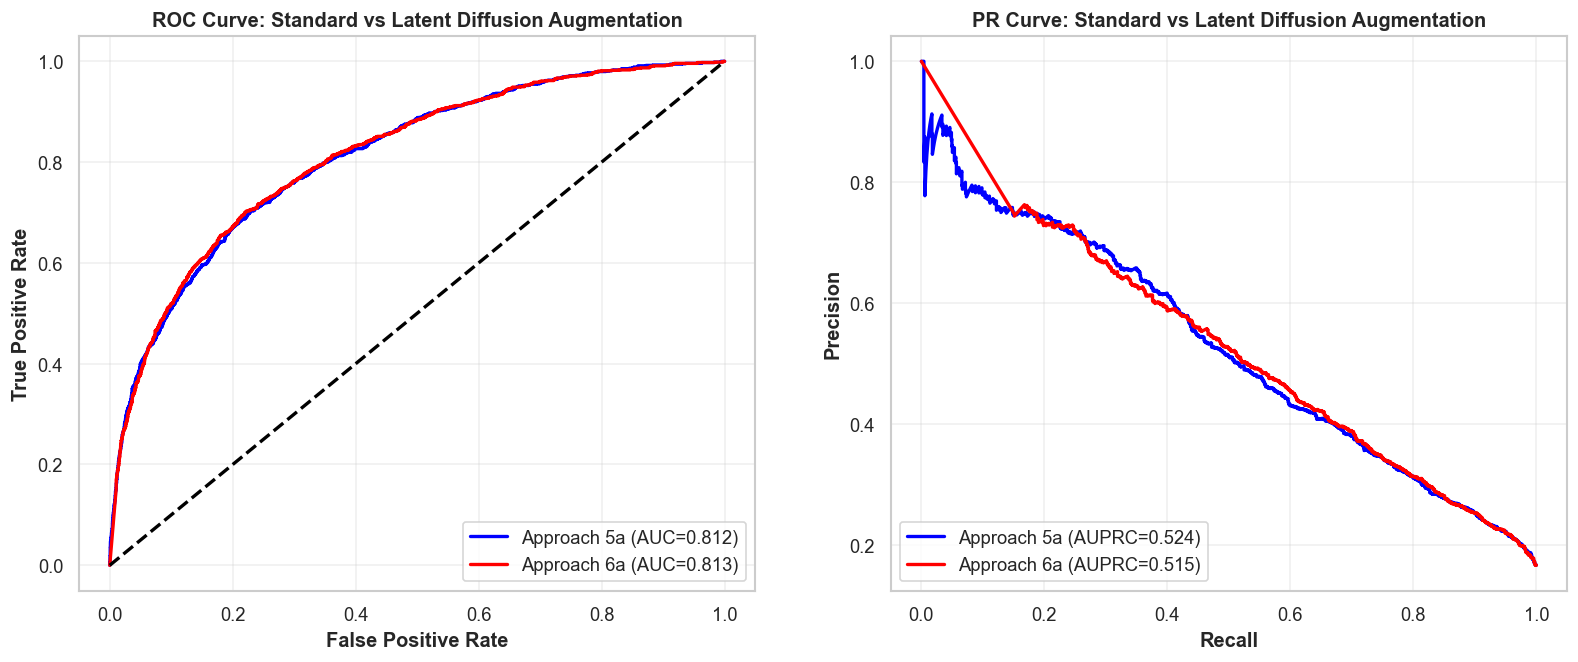

In [70]:
import pandas as pd
from sklearn.metrics import roc_curve, auc
import os

if 'result_6a' in locals() and 'result_5a' in locals():
    comp_6 = {
        "Approach 5a\n(Standard DiffAug)": {
            "AUROC": result_5a.auroc,
            "AUPRC": result_5a.auprc,
            "Challenge Score": result_5a.challenge_score,
            "ECE": ece_5a,
            "F1": result_5a.f1
        },
        "Approach 6a\n(Latent DiffAug + Calib)": {
            "AUROC": result_6a.auroc,
            "AUPRC": result_6a.auprc,
            "Challenge Score": result_6a.challenge_score,
            "ECE": ece_6a,
            "F1": result_6a.f1
        }
    }
    
    df_comp_6 = pd.DataFrame(comp_6).T
    print("\n" + "="*70)
    print("  APPROACH 5 vs APPROACH 6 COMPARISON (Test Set)")
    print("="*70)
    print(df_comp_6.to_string(float_format="{:.4f}".format))
    print("="*70)
    
    from sklearn.metrics import roc_curve, precision_recall_curve, auc
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    fpr5, tpr5, _ = roc_curve(y_true_5a, y_prob_5a)
    ax1.plot(fpr5, tpr5, label=f'Approach 5a (AUC={result_5a.auroc:.3f})', color='blue', lw=2)
    
    fpr6, tpr6, _ = roc_curve(y_true_6a, y_prob_6a)
    ax1.plot(fpr6, tpr6, label=f'Approach 6a (AUC={result_6a.auroc:.3f})', color='red', lw=2)
    
    ax1.plot([0, 1], [0, 1], 'k--', lw=2)
    ax1.set_xlabel('False Positive Rate', fontweight='bold')
    ax1.set_ylabel('True Positive Rate', fontweight='bold')
    ax1.set_title('ROC Curve: Standard vs Latent Diffusion Augmentation', fontweight='bold')
    ax1.legend(loc="lower right")
    ax1.grid(alpha=0.3)
    
    precision5, recall5, _ = precision_recall_curve(y_true_5a, y_prob_5a)
    ax2.plot(recall5, precision5, label=f'Approach 5a (AUPRC={result_5a.auprc:.3f})', color='blue', lw=2)
    
    precision6, recall6, _ = precision_recall_curve(y_true_6a, y_prob_6a)
    ax2.plot(recall6, precision6, label=f'Approach 6a (AUPRC={result_6a.auprc:.3f})', color='red', lw=2)
    
    ax2.set_xlabel('Recall', fontweight='bold')
    ax2.set_ylabel('Precision', fontweight='bold')
    ax2.set_title('PR Curve: Standard vs Latent Diffusion Augmentation', fontweight='bold')
    ax2.legend(loc="lower left")
    ax2.grid(alpha=0.3)
    
    os.makedirs('approach6', exist_ok=True)
    plt.savefig('approach6/comparison_5_vs_6_roc_pr.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("Ensure both Approach 5a and Approach 6a have been evaluated.")

### 14.9 Approach 6b - latent diffusion classifier (zero-shot)

Same idea as 5b but in latent space.

In [71]:
@torch.no_grad()
def physics_diffusion_classify(model, schedule, x, cfg, device, ae, latent_scale, T_steps=10, lambda_phys=0.05, min_amp=-7.0, max_amp=7.0):
    model.eval()
    ae.eval()
    B = x.shape[0]

    timesteps = torch.linspace(1, cfg["T"] - 1, T_steps, dtype=torch.long, device=device)
    score_diff = torch.zeros(B, device=device)

    for t_val in timesteps:
        t = torch.full((B,), t_val, device=device, dtype=torch.long)
        noise = torch.randn_like(x)
        x_t = schedule.q_sample(x, t, noise)

        y_pos = torch.ones(B, device=device, dtype=torch.long)
        y_neg = torch.zeros(B, device=device, dtype=torch.long)

        v_pos = model(x_t, t, y_pos, cfg_dropout=0.0)
        v_neg = model(x_t, t, y_neg, cfg_dropout=0.0)
        
        alpha_bar_t = schedule.alphas_cumprod[t].view(-1, 1, 1)
        target_v = torch.sqrt(alpha_bar_t) * noise - torch.sqrt(1 - alpha_bar_t) * x

        mse_pos = ((v_pos - target_v) ** 2).mean(dim=(1, 2))
        mse_neg = ((v_neg - target_v) ** 2).mean(dim=(1, 2))

        z_0_pred_pos = torch.sqrt(alpha_bar_t) * x_t - torch.sqrt(1 - alpha_bar_t) * v_pos
        x_0_pred_pos_padded = ae.decoder(z_0_pred_pos / latent_scale)
        x_0_pred_pos = x_0_pred_pos_padded[:, :, 12:-12]
        penalty_high_pos = torch.relu(x_0_pred_pos - max_amp)
        penalty_low_pos = torch.relu(min_amp - x_0_pred_pos)
        weight = (1.0 - t.float() / cfg["T"])
        phys_loss_pos = (penalty_high_pos + penalty_low_pos).mean(dim=(1, 2)) * lambda_phys * weight

        z_0_pred_neg = torch.sqrt(alpha_bar_t) * x_t - torch.sqrt(1 - alpha_bar_t) * v_neg
        x_0_pred_neg_padded = ae.decoder(z_0_pred_neg / latent_scale)
        x_0_pred_neg = x_0_pred_neg_padded[:, :, 12:-12]
        penalty_high_neg = torch.relu(x_0_pred_neg - max_amp)
        penalty_low_neg = torch.relu(min_amp - x_0_pred_neg)
        phys_loss_neg = (penalty_high_neg + penalty_low_neg).mean(dim=(1, 2)) * lambda_phys * weight

        total_loss_pos = mse_pos + phys_loss_pos
        total_loss_neg = mse_neg + phys_loss_neg

        score_diff += total_loss_neg - total_loss_pos

    score_diff /= T_steps
    return score_diff.cpu().numpy()

print("Evaluating Approach 6b (Latent Diffusion Classifier with Physics Penalty)...")
ldm_unet.eval()
ae.eval()

val_scores_6b = []
val_labels_6b = []
for signals, labels in tqdm(val_loader, desc="LDM classify (val)"):
    signals = signals.to(device)
    with torch.no_grad():
        _, latents = ae(signals)
        latents = latents * LATENT_SCALE
    scores = physics_diffusion_classify(
        ldm_unet, schedule, latents, CFG, device, ae, LATENT_SCALE,
        T_steps=CFG["classify_T_steps"],
        lambda_phys=0.05, min_amp=EMPIRICAL_MIN_AMP, max_amp=EMPIRICAL_MAX_AMP
    )
    val_scores_6b.extend(scores.tolist())
    val_labels_6b.extend(labels.numpy().astype(int).tolist())
    if device.type == "mps": torch.mps.empty_cache()

scaler_6b = LogisticRegression()
scaler_6b.fit(np.array(val_scores_6b).reshape(-1, 1), np.array(val_labels_6b))

all_probs_6b = []
all_labels_6b = []

for signals, labels in tqdm(test_loader, desc="LDM classify (test)"):
    signals = signals.to(device)
    with torch.no_grad():
        _, latents = ae(signals)
        latents = latents * LATENT_SCALE
    scores = physics_diffusion_classify(
        ldm_unet, schedule, latents, CFG, device, ae, LATENT_SCALE,
        T_steps=CFG["classify_T_steps"],
        lambda_phys=0.05, min_amp=EMPIRICAL_MIN_AMP, max_amp=EMPIRICAL_MAX_AMP
    )
    probs = scaler_6b.predict_proba(np.array(scores).reshape(-1, 1))[:, 1]
    all_probs_6b.extend(probs.tolist())
    all_labels_6b.extend(labels.numpy().astype(int).tolist())
    
    if device.type == "mps": torch.mps.empty_cache()

y_true_6b = np.array(all_labels_6b)
y_prob_6b = np.array(all_probs_6b)

val_prob_6b = scaler_6b.predict_proba(np.array(val_scores_6b).reshape(-1, 1))[:, 1]
opt_thr_6b = find_optimal_threshold(np.array(val_labels_6b), val_prob_6b, metric="f1")
result_6b = compute_metrics(y_true_6b, y_prob_6b, threshold=opt_thr_6b)
ece_6b = compute_ece(y_true_6b, y_prob_6b)

print(f"\n{'='*60}")
print(f"  APPROACH 6b: Latent Diffusion Classifier (Test Set)")
print(f"{'='*60}")
print(f"  AUROC           : {result_6b.auroc:.4f}")
print(f"  AUPRC           : {result_6b.auprc:.4f}")
print(f"  Challenge Score : {result_6b.challenge_score:.4f}")
print(f"  ECE             : {ece_6b:.4f}")
print(f"  Opt threshold   : {opt_thr_6b:.3f}")
print(f"  F1              : {result_6b.f1:.4f}")
print(f"  Sensitivity     : {result_6b.sensitivity:.4f}")
print(f"  Specificity     : {result_6b.specificity:.4f}")
print(f"{'='*60}")

Evaluating Approach 6b (Latent Diffusion Classifier with Physics Penalty)...


LDM classify (test): 100%|██████████| 922/922 [27:19<00:00,  1.78s/it]



  APPROACH 6b: Latent Diffusion Classifier (Test Set)
  AUROC           : 0.7609
  AUPRC           : 0.4262
  Challenge Score : 0.1888
  ECE             : 0.0001
  Opt threshold   : 0.173
  F1              : 0.4307
  Sensitivity     : 0.3841
  Specificity     : 0.9201


### 14.10 Approach 6c - ensemble (ResNet 6a + LDM classifier 6b)

In [72]:
if 'y_prob_6a' in locals() and 'y_prob_6b' in locals():
    y_prob_6c = (y_prob_6a + y_prob_6b) / 2.0
    y_true_6c = y_true_6a
    
    val_prob_6a_calib = torch.sigmoid(temp_scaler_6a(val_logits_6a)).detach().numpy()
    val_prob_6b_calib = scaler_6b.predict_proba(np.array(val_scores_6b).reshape(-1, 1))[:, 1]
    val_prob_6c = (val_prob_6a_calib + val_prob_6b_calib) / 2.0
    opt_thr_6c = find_optimal_threshold(np.array(val_labels_6a), val_prob_6c, metric="f1")
    result_6c = compute_metrics(y_true_6c, y_prob_6c, threshold=opt_thr_6c)
    ece_6c = compute_ece(y_true_6c, y_prob_6c)
    
    print(f"\n{'='*60}")
    print(f"  APPROACH 6c: Ensemble Classifier (Test Set)")
    print(f"{'='*60}")
    print(f"  AUROC           : {result_6c.auroc:.4f}")
    print(f"  AUPRC           : {result_6c.auprc:.4f}")
    print(f"  Challenge Score : {result_6c.challenge_score:.4f}")
    print(f"  ECE             : {ece_6c:.4f}")
    print(f"  Opt threshold   : {opt_thr_6c:.3f}")
    print(f"  F1              : {result_6c.f1:.4f}")
    print(f"  Sensitivity     : {result_6c.sensitivity:.4f}")
    print(f"  Specificity     : {result_6c.specificity:.4f}")
    print(f"{'='*60}")
else:
    print("Run Approach 6a and 6b first to generate ensemble predictions.")


  APPROACH 6c: Ensemble Classifier (Test Set)
  AUROC           : 0.7841
  AUPRC           : 0.4957
  Challenge Score : 0.2181
  ECE             : 0.0791
  Opt threshold   : 0.089
  F1              : 0.4804
  Sensitivity     : 0.4044
  Specificity     : 0.9442


### 14.11 Approach 5 vs Approach 6

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import roc_curve, precision_recall_curve

if 'y_prob_5b' in locals() and 'y_prob_6b' in locals():
    fpr5b, tpr5b, _ = roc_curve(y_true_5b, y_prob_5b)
    precision5b, recall5b, _ = precision_recall_curve(y_true_5b, y_prob_5b)
    
    fpr6b, tpr6b, _ = roc_curve(y_true_6b, y_prob_6b)
    precision6b, recall6b, _ = precision_recall_curve(y_true_6b, y_prob_6b)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    ax1.plot(fpr5b, tpr5b, label=f'Approach 5b (AUC={result_5b.auroc:.3f})', color='blue', lw=2)
    ax1.plot(fpr6b, tpr6b, label=f'Approach 6b (AUC={result_6b.auroc:.3f})', color='red', lw=2)
    ax1.plot([0, 1], [0, 1], 'k--', lw=2)
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title('ROC Curve: Zero-Shot Classifiers (5b vs 6b)')
    ax1.legend(loc='lower right')
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(recall5b, precision5b, label=f'Approach 5b (AUPRC={result_5b.auprc:.3f})', color='blue', lw=2)
    ax2.plot(recall6b, precision6b, label=f'Approach 6b (AUPRC={result_6b.auprc:.3f})', color='red', lw=2)
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.set_title('PR Curve: Zero-Shot Classifiers (5b vs 6b)')
    ax2.legend(loc='lower left')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('approach6/comparison_5b_vs_6b_roc_pr.png', dpi=300, bbox_inches='tight')
    plt.show()

if 'y_prob_5c' in locals() and 'y_prob_6c' in locals():
    fpr5c, tpr5c, _ = roc_curve(y_true_5c, y_prob_5c)
    precision5c, recall5c, _ = precision_recall_curve(y_true_5c, y_prob_5c)
    
    fpr6c, tpr6c, _ = roc_curve(y_true_6c, y_prob_6c)
    precision6c, recall6c, _ = precision_recall_curve(y_true_6c, y_prob_6c)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    ax1.plot(fpr5c, tpr5c, label=f'Approach 5c (AUC={result_5c.auroc:.3f})', color='blue', lw=2)
    ax1.plot(fpr6c, tpr6c, label=f'Approach 6c (AUC={result_6c.auroc:.3f})', color='red', lw=2)
    ax1.plot([0, 1], [0, 1], 'k--', lw=2)
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title('ROC Curve: Ensembles (5c vs 6c)')
    ax1.legend(loc='lower right')
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(recall5c, precision5c, label=f'Approach 5c (AUPRC={result_5c.auprc:.3f})', color='blue', lw=2)
    ax2.plot(recall6c, precision6c, label=f'Approach 6c (AUPRC={result_6c.auprc:.3f})', color='red', lw=2)
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.set_title('PR Curve: Ensembles (5c vs 6c)')
    ax2.legend(loc='lower left')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('approach6/comparison_5c_vs_6c_roc_pr.png', dpi=300, bbox_inches='tight')
    plt.show()

if all(var in locals() for var in ['result_5a', 'result_5b', 'result_5c', 'result_6a', 'result_6b', 'result_6c']):    
    data = {
        'Approach': ['5a (ResNet+DiffAug)', '5b (Diff Clf)', '5c (Ensemble)', '6a (ResNet+LDM+Calib)', '6b (LDM Clf)', '6c (LDM Ensemble)'] * 3,
        'Metric': ['AUROC']*6 + ['AUPRC']*6 + ['Challenge Score']*6,
        'Score': [
            result_5a.auroc, result_5b.auroc, result_5c.auroc, result_6a.auroc, result_6b.auroc, result_6c.auroc,
            result_5a.auprc, result_5b.auprc, result_5c.auprc, result_6a.auprc, result_6b.auprc, result_6c.auprc,
            result_5a.challenge_score, result_5b.challenge_score, result_5c.challenge_score, result_6a.challenge_score, result_6b.challenge_score, result_6c.challenge_score
        ]
    }
    
    df_plot = pd.DataFrame(data)
    
    plt.figure(figsize=(14, 8))
    sns.barplot(data=df_plot, x='Metric', y='Score', hue='Approach', palette='Paired')
    plt.title('Performance Comparison: Approach 5 vs Approach 6')
    plt.ylim(0, 1.0)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('approach6/comparison_all_metrics_bar.png', dpi=300, bbox_inches='tight')
    plt.show()